# The Articulation Story — §4.1–4.3 (v4)

*2026-08-11. Scope = **unsupervised metrics only** (no hotpot/hover/etc. except the supervised-ladder appendix). Four sections, per discussion: **4.1** codability, **4.2** prompt parts, **4.2E** examples, **4.3** scaling laws. Paper-figure replicas and last week's new instruments are folded into their sections. All data is repo-local: `outputs/articulation_story_20260810/` (the 465MB pack), `outputs/analyses/`, `notebooks/data/2026-07-07-osl-multi/`.*

### Glossary

| term | meaning |
|---|---|
| **recovery** | balanced accuracy of a receiver's per-text binary predictions against the reference labels (threshold-free convention: class-balanced, ties dropped) |
| **reference** | 2-voter consensus (llama70b + qwen25-72b, disagreements dropped); channel cells add GLM voters where noted; leave-one-out when a voter is scored |
| **channel / arm** | what the receiver is shown about the construct: `name`, `definition`, `definition_padded` (length control), `explanation`, `dossier`, `dossier_mismatched` (content control), `examples` (flip-selected texts), `examples_mm` (donor-swapped control) |
| **z** | capability index: logit-AUC on a frozen anchor battery (14 executors, 5 families) |
| **construct classes (blind)** | `norm-boundary` / `mechanics` / `other` — blind categorization of the 203 v3sets constructs |
| **units** | atomic requirements decomposed from a metric definition, blind-labeled MECHANICAL / STRUCTURAL_CRAFT / TASTE (3 crews, 6/6 calibration anchors) |
| **PLANTED** | synthetic constructs with known decision rules, used as instrument controls |

### The week's instruments (2026-08-05 → 08-11), where each lives now

| instrument | section | artifact |
|---|---|---|
| three-family saturation census | 4.3d | `analyses/family_verdict_join_v1.json` |
| reference-reliability filter + remedy table | 4.3e | `outputs/analyses/reliability_filter_v1/`, `verdict_table_v1/` |
| de-censor test (frontier vs local) | 4.3f | `analyses/decensor_harvest_v1.json` |
| frontier limit question (gate/gap) | 4.2E-c | `analyses/frontier_limit_humor_v2.json` |
| channel × capability exhibit (LOO refs) | 4.2c | `outputs/analyses/channel_scale_v2/` |
| examples-at-scale two-receiver ledger | 4.2E-b | `analyses/v3sets_ledger_v1.json` |
| MI upper-bound census | 4.3g | `analyses/mi_upper_census_v2.json` |
| ladder validation (P1–P3 prereg) | 4.3h | `outputs/analyses/ladder_p123_v1/` |

### Pipeline roles (disambiguation — three different "models" in this paper)

| role | what it does | fixed or varied? |
|---|---|---|
| **encoder** | applies the original prompt *p* to texts → labels m_ω (reconstruction instrument, §3) | fixed |
| **decoder** | sees only (text, label) pairs — never *p* — and reconstructs a prompt *p′* | fixed |
| **executor / listener / judge** | applies an articulation (or both *p* and *p′*) to probe texts; agreement with the reference is "recovery" | **this is the axis we scale** |
| **reference voters** | frontier consensus (llama-70B + qwen2.5-72B, + GLM-4.7/5.2 on channel cells) defining ground-truth labels | fixed; LOO when a voter is scored |

Within one MI cell the *same* executor applies both p and p′ (so model idiosyncrasy cancels); the known self-consistency caveat (a voter scoring its own reference) is handled by leave-one-out and non-voter headline receivers throughout.

In [1]:
import glob, json, os, re, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from scipy import stats as sps
D = "../outputs/articulation_story_20260810"
TASKS = ["humor", "creative_writing", "math", "peer_review", "news_homepages"]
ZTASKS = ["humor", "creative_writing", "math", "peer_review"]   # zxa-channel tasks (news excluded from joins)
RCOL = {"RISING": "#b03a2e", "REACHES": "#2c5aa0", "BOUNDED": "#ca6f1e", "NOISY": "0.6"}
def lp(p):
    if not os.path.exists(p): return {}
    z = np.load(p, allow_pickle=True)
    return {str(n): z["m_bar"][i] for i, n in enumerate([str(x) for x in z["names"]])}
def balanced(pred, lab):
    ok = (lab >= 0) & np.isfinite(pred)
    if ok.sum() < 30: return None
    p = (pred[ok] > .5).astype(int); l = lab[ok]
    accs = [float(np.mean(p[l == c] == c)) for c in (0, 1) if (l == c).sum() >= 5]
    return float(np.mean(accs)) if len(accs) == 2 else None
_rng = np.random.default_rng(0)
def ci20(d):
    d = np.asarray([x for x in d if x is not None and np.isfinite(x)], float)
    bm = d[_rng.integers(0, len(d), size=(20000, len(d)))].mean(1)
    return d.mean(), np.percentile(bm, 2.5), np.percentile(bm, 97.5)
# family split for receiver panels (never connect a line across families)
FAMS = {"llama": ["llama1b", "llama3b", "llama8b", "llama70b"],
        "qwen2.5": ["qwen25-3b", "qwen25-7b", "qwen25-14b", "qwen25-32b", "qwen25-72b"],
        "(isolated)": ["mistral7b", "gemma2-27b", "phi4", "gpt-oss-120b"]}
FCOL = {"llama": "#2c5aa0", "qwen2.5": "#b03a2e", "(isolated)": "0.45"}

## 4.1 Codability — what fraction of each metric's requirements can code check?

Each metric definition is decomposed into atomic **units**, each blind-labeled `MECHANICAL` (a deterministic program could check it) / `STRUCTURAL_CRAFT` (inspectable compositional property — needs language understanding but has a describable decision procedure) / `TASTE` (graded holistic judgment) by independent crews that must first label 6 calibration anchors 6/6. A metric's **% codable** = share of its units labeled MECHANICAL.

**Coverage (updated 2026-08-11)**: the original wave covered the five crowd-panel tasks (1,032 metrics / 3,458 units). The **extension wave now adds the three remaining OSL domains** — press-releases (220 metrics / 902 units), notice-and-comment (88 / 332), patents (7 / 26) — same protocol, same 6 anchors, every crew 6/6. Total: **1,347 metrics / 4,718 units across 8 domains**. Definitions for the new domains come from the same canonical source as the originals (`outputs/hierarchy/<task>_general_r2_expanded.json`, 100% name-match).

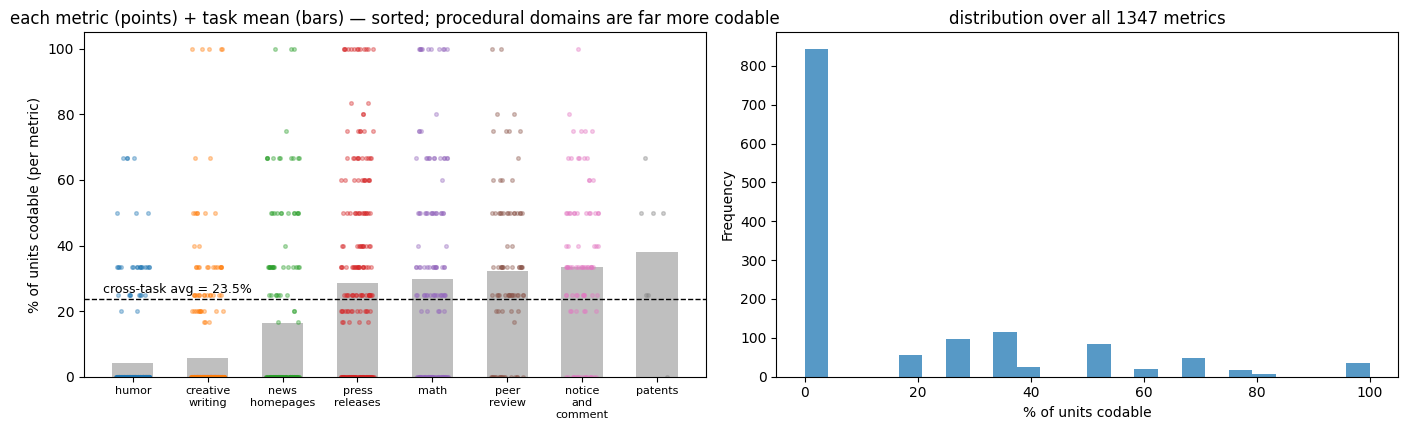

,n_metrics,n_units,mean_pct_codable,pct_fully_uncodable,mean_pct_taste
task,,,,,
humor,284,968,4.2,88.4,30.7
creative_writing,369,1246,5.6,84.8,21.3
news_homepages,150,458,16.4,64.0,10.2
press_releases,220,902,28.5,39.5,12.1
math,141,455,29.8,40.4,5.2
peer_review,88,331,32.3,22.7,6.9
notice_and_comment,88,332,33.5,21.6,9.8
patents,7,26,38.1,14.3,7.1


In [2]:
# 4.1a — per-metric % codable: strip (every metric) + task means + distribution. 8 tasks.
TASKS8 = TASKS + ["press_releases", "notice_and_comment", "patents"]
cod = {}
for t in TASKS8:
    d = json.load(open(f"{D}/code_metrics/unit_codability_{t}.json"))["metrics"]
    for name, units in d.items():
        labs = [u["label"] for u in units]
        cod[(t, name)] = {"n_units": len(labs),
                          "pct_codable": 100 * sum(l == "MECHANICAL" for l in labs) / len(labs),
                          "pct_taste": 100 * sum(l == "TASTE" for l in labs) / len(labs)}
dfc = pd.DataFrame([{"task": t, "metric": n, **v} for (t, n), v in cod.items()])
ORD8 = list(dfc.groupby("task")["pct_codable"].mean().sort_values().index)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
means = dfc.groupby("task")["pct_codable"].mean().reindex(ORD8)
for i, t in enumerate(ORD8):
    y = dfc[dfc.task == t]["pct_codable"].values
    axes[0].scatter(i + _rng.uniform(-.22, .22, len(y)), y, s=7, alpha=.35)
axes[0].bar(range(len(ORD8)), means.values, width=.55, alpha=.25, color="k", zorder=0)
axes[0].axhline(means.mean(), color="k", ls="--", lw=1)
axes[0].text(-.4, means.mean() + 2, f"cross-task avg = {means.mean():.1f}%", fontsize=9)
axes[0].set_xticks(range(len(ORD8)))
axes[0].set_xticklabels([t.replace("_", "\n") for t in ORD8], fontsize=8)
axes[0].set_ylabel("% of units codable (per metric)")
axes[0].set_title("each metric (points) + task mean (bars) — sorted; procedural domains are far more codable")
dfc["pct_codable"].plot(kind="hist", bins=24, ax=axes[1], alpha=.75)
axes[1].set_xlabel("% of units codable"); axes[1].set_title(f"distribution over all {len(dfc)} metrics")
plt.tight_layout(); plt.show()
display(dfc.groupby("task").agg(n_metrics=("metric", "count"), n_units=("n_units", "sum"),
        mean_pct_codable=("pct_codable", "mean"),
        pct_fully_uncodable=("pct_codable", lambda s: 100 * (s == 0).mean()),
        mean_pct_taste=("pct_taste", "mean")).round(1).reindex(ORD8))

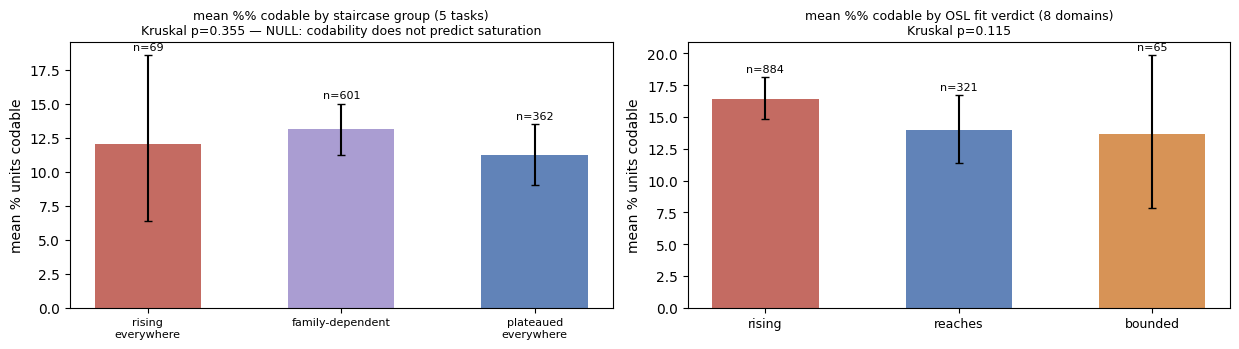

TAKEAWAY: the formal-language seam (codability) and the listener-scaling boundary are
largely independent axes — knowing a construct is code-checkable tells you little about
whether more capability helps a judge recover it.


In [3]:
# 4.1b — does codability predict the scaling verdict? Two joins:
#  LEFT: three-family staircase saturation groups (5 crowd-panel tasks; threshold rule).
#  RIGHT: OSL fit verdicts (all 8 domains; AICc rule, see 4.3 header).
FJ = json.load(open(f"{D}/analyses/family_verdict_join_v1.json"))["full_rows"]
def satgroup(r, t=.02):
    tm = [v for v in r["top_minus_mid"].values() if v is not None]
    if len(tm) < 3: return None
    if all(v > t for v in tm): return "rising everywhere"
    if all(v <= t for v in tm): return "plateaued everywhere"
    return "family-dependent"
GROUP = {(r["task"], r["name"]): satgroup(r) for r in FJ}
dfc["satgroup"] = [GROUP.get((t, n)) for t, n in zip(dfc.task, dfc.metric)]
OSLV = {}
for t in TASKS8:
    for n, v in json.load(open(f"data/2026-07-07-osl-multi/curves_{t}.json")).items():
        if v.get("kind") == "bank": OSLV[(t, n)] = v.get("verdict")
dfc["oslv"] = [OSLV.get((t, n)) for t, n in zip(dfc.task, dfc.metric)]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.6))
order = ["rising everywhere", "family-dependent", "plateaued everywhere"]
GC = {"rising everywhere": "#b03a2e", "family-dependent": "#8e7cc3", "plateaued everywhere": "#2c5aa0"}
sub = dfc[dfc.satgroup.notna()]
for i, g in enumerate(order):
    d = sub[sub.satgroup == g]["pct_codable"].values
    m, lo, hi = ci20(d)
    axes[0].bar(i, m, .55, color=GC[g], alpha=.75)
    axes[0].errorbar(i, m, yerr=[[m - lo], [hi - m]], color="k", capsize=3)
    axes[0].text(i, hi + .4, f"n={len(d)}", ha="center", fontsize=8)
axes[0].set_xticks(range(3)); axes[0].set_xticklabels([g.replace(" ", "\n") for g in order], fontsize=8)
kw = sps.kruskal(*[sub[sub.satgroup == g]["pct_codable"].values for g in order])
axes[0].set_title(f"mean %% codable by staircase group (5 tasks)\nKruskal p={kw.pvalue:.3g} — NULL: codability does not predict saturation", fontsize=9)
sub2 = dfc[dfc.oslv.isin(["RISING", "REACHES", "BOUNDED"])]
for i, g in enumerate(["RISING", "REACHES", "BOUNDED"]):
    d = sub2[sub2.oslv == g]["pct_codable"].values
    m, lo, hi = ci20(d)
    axes[1].bar(i, m, .55, color=RCOL[g], alpha=.75)
    axes[1].errorbar(i, m, yerr=[[m - lo], [hi - m]], color="k", capsize=3)
    axes[1].text(i, hi + .4, f"n={len(d)}", ha="center", fontsize=8)
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(["rising", "reaches", "bounded"], fontsize=9)
kw2 = sps.kruskal(*[sub2[sub2.oslv == g]["pct_codable"].values for g in ("RISING", "REACHES", "BOUNDED")])
axes[1].set_title(f"mean %% codable by OSL fit verdict (8 domains)\nKruskal p={kw2.pvalue:.3g}", fontsize=9)
for ax in axes: ax.set_ylabel("mean % units codable")
plt.tight_layout(); plt.show()
print("TAKEAWAY: the formal-language seam (codability) and the listener-scaling boundary are")
print("largely independent axes — knowing a construct is code-checkable tells you little about")
print("whether more capability helps a judge recover it.")

### 4.1c Judged codability vs what actually compiles (seam width F)

The §4.1 numbers are **judgments** (a blind crew deciding "a program could check this"). The metric-seam program produced the **behavioral** counterpart: per task, hybrid metrics were actually *built* — deterministic code + an LLM component — and evaluated held-out. **F = A/(V+A)**: per criterion, V = held-out correlation of the best code-only implementation against the reference judge, V+A = held-out correlation of the full LLM-carried system; F is the fraction of achieved signal the LLM layer must carry (medians over each bank; conservative where seed-prompts were used, since optimization can only raise V+A). So **1−F = share of signal carried by real, certified code** — signal-weighted and implementation-verified, unlike the unit counts. How well do the two agree?

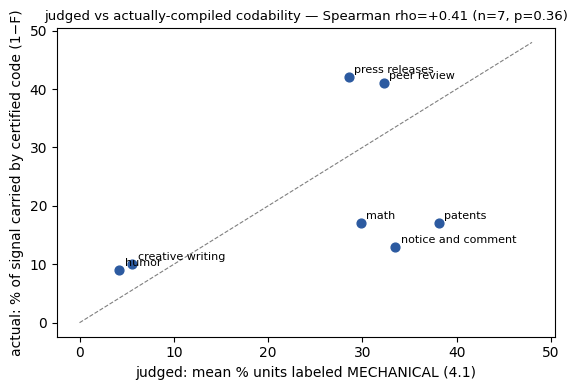

READ: weakly positive, NOT significant. The coarse split (humor/CW low vs rest) agrees,
but technical registers inflate JUDGED codability: patents (38% judged / 17% compiled),
notice-and-comment (34% / 13%) read as mechanical without compiling; press/peer compile
at ~42% on ~30% judged. Unit-level version of the same lesson: the seam E2 sweep took 20
codable-looking criteria -> 9 function-wall kills, 0/20 promoted held-out. Discipline:
4.1 numbers are 'judged codable'; the certified F spectrum is the behavioral instrument.


In [4]:
# 4.1c — judged %-codable (unit counts) vs compiled share 1-F (certified seam spectrum).
FSPEC = {"humor": .91, "creative_writing": .90, "notice_and_comment": .87, "math": .83,
         "patents": .83, "peer_review": .59, "press_releases": .58}
jt = dfc.groupby("task")["pct_codable"].mean()
common = sorted(set(jt.index) & set(FSPEC))
J = [jt[t] for t in common]; A = [100 * (1 - FSPEC[t]) for t in common]
rho, p = sps.spearmanr(J, A)
fig, ax = plt.subplots(figsize=(5.8, 4))
ax.scatter(J, A, s=40, color="#2c5aa0")
for t, x, y in zip(common, J, A):
    ax.annotate(t.replace("_", " "), (x, y), fontsize=8, xytext=(4, 3), textcoords="offset points")
lim = [0, max(max(J), max(A)) + 6]
ax.plot(lim, lim, "k--", lw=.8, alpha=.5)
ax.set_xlabel("judged: mean % units labeled MECHANICAL (4.1)")
ax.set_ylabel("actual: % of signal carried by certified code (1−F)")
ax.set_title(f"judged vs actually-compiled codability — Spearman rho={rho:+.2f} (n={len(common)}, p={p:.2f})", fontsize=9.5)
plt.tight_layout(); plt.show()
print("READ: weakly positive, NOT significant. The coarse split (humor/CW low vs rest) agrees,")
print("but technical registers inflate JUDGED codability: patents (38% judged / 17% compiled),")
print("notice-and-comment (34% / 13%) read as mechanical without compiling; press/peer compile")
print("at ~42% on ~30% judged. Unit-level version of the same lesson: the seam E2 sweep took 20")
print("codable-looking criteria -> 9 function-wall kills, 0/20 promoted held-out. Discipline:")
print("4.1 numbers are 'judged codable'; the certified F spectrum is the behavioral instrument.")

### 4.1d Is a 100%-codable metric equivalent to a planted metric? (No — and the gap is the finding)

**Planted constructs** = synthetic criteria with known, trivial, text-local decision rules ("This text contains at least one question mark"), run through the identical pipeline as instrument controls (spike-ins). Conjecture: a mined metric whose units are all judged MECHANICAL should behave the same. Test below: it doesn't. Planted-equivalence requires **100% codable ∧ text-local ∧ single-rule ∧ implemented** — mined fully-codable metrics fail on text-locality ("Previously unpublished work only": mechanical *given a database*, invisible in the text) and execution cost ("Consistency of symbol meaning and notation": trivial for code, expensive for an in-context LLM judge). This operationalizes the intro's Daston thin/thick footnote: planted = thin rules; codable-but-rising = **mechanical-but-thick** (deterministic in the world, unrecoverable from the artifact alone) — a different failure than tacitness, with a different remedy.

In [5]:
# 4.1d — fully-codable mined metrics vs planted behavior.
full = dfc[dfc.pct_codable == 100].copy()
OSLV = {}; LMAP = {}
for t in TASKS8:
    for n, v in json.load(open(f"data/2026-07-07-osl-multi/curves_{t}.json")).items():
        if v.get("kind") == "bank":
            OSLV[(t, n)] = v.get("verdict"); LMAP[(t, n)] = v.get("L")
full["oslv"] = [OSLV.get((t, n)) for t, n in zip(full.task, full.metric)]
full["L"] = [LMAP.get((t, n)) for t, n in zip(full.task, full.metric)]
print(f"100%-codable mined metrics: {len(full)} | verdicts: {dict(Counter(full.oslv.dropna()))}")
print("If they were planted-equivalent: early saturation at the instrument ceiling. Instead 23/35 still RISING.")
rest_L = [LMAP[k] for k in LMAP if LMAP[k] is not None and k not in
          set(zip(full.task, full.metric))]
fL = full["L"].dropna()
print(f"fitted ceiling L: 100%-codable med {fL.median():.3f} vs rest {np.median(rest_L):.3f} "
      f"(MW p={sps.mannwhitneyu(fL, rest_L).pvalue:.2f}) — indistinguishable")
display(full.sort_values("L")[["task", "metric", "oslv", "L", "n_units"]].head(10))
print("Bottom rows are the mechanical-but-thick cases: deterministic rules whose evidence")
print("is not in the probe text (publication status, canon databases, external standards).")

100%-codable mined metrics: 35 | verdicts: {'RISING': 23, 'REACHES': 9, 'NOISY': 2, 'BOUNDED': 1}
If they were planted-equivalent: early saturation at the instrument ceiling. Instead 23/35 still RISING.
fitted ceiling L: 100%-codable med 0.792 vs rest 0.817 (MW p=0.69) — indistinguishable


,task,metric,oslv,L,n_units
1268,notice_and_comment,Clarity on consultation scope and objectives,RISING,0.363,2
929,news_homepages,Engagement and ranking signals (platform algor...,BOUNDED,0.372,4
1099,press_releases,Earned media measurement and analytics,RISING,0.464,2
671,math,Code and algorithm presentation clarity,RISING,0.477,5
523,creative_writing,Previously unpublished work only,RISING,0.483,1
683,math,Declare notation before use,RISING,0.483,2
954,news_homepages,Leads that answer 5W1H,REACHES,0.502,2
869,peer_review,"Software availability, maintenance, and eviden...",REACHES,0.524,3
719,math,Lead with the main results,RISING,0.595,3
492,creative_writing,Originality and plagiarism compliance,RISING,0.638,2


Bottom rows are the mechanical-but-thick cases: deterministic rules whose evidence
is not in the probe text (publication status, canon databases, external standards).


## 4.2 Prompt parts — which text segments carry the construct?

**Arms** (all at receiver = llama70b; reference = multi-voter consensus on the dossier arm): `name` → `definition` → `definition_padded` (same length as explanation, no new content — the length control) → `explanation` (adds mechanism) → `dossier` (everything) → `dossier_mismatched` (a *different* construct's dossier — the content control). **Scope**: all six arms exist only for the 41-base authored slate (n=32 after reference requirements) — 4.2a/b are slate-scale; 4.2c is the full-bank view (rubric + examples channels, 284 humor constructs). Channels are **categories, not a continuum**, so everything here is box/strip plots (per user 2026-08-11); the old connected-line version is retired.

Presentation: (a) distribution per arm; (b) paired *gains over bare name*; (c) **where the mean hides structure** — per-metric winning arm and the metrics where the ordering inverts; (d) the capability interaction (channel × receiver, family-split).

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_39300/2108168059.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data, labels=ARMS, showfliers=False, patch_artist=True)


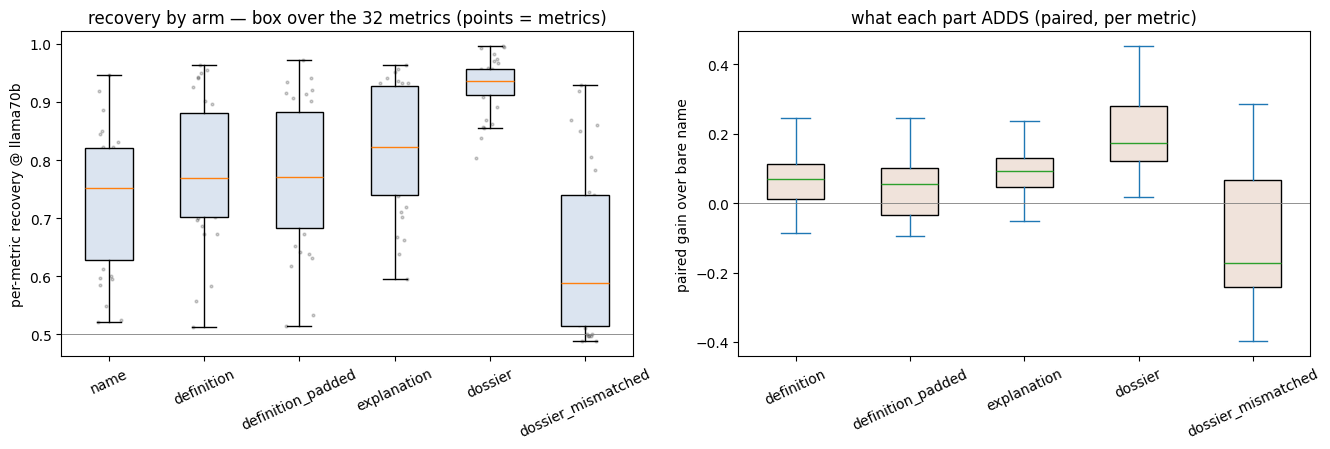

definition             gain over name = +0.056  CI[+0.021,+0.088]  n=32
definition_padded      gain over name = +0.037  CI[+0.003,+0.069]  n=32
explanation            gain over name = +0.088  CI[+0.054,+0.122]  n=32
dossier                gain over name = +0.197  CI[+0.158,+0.237]  n=32
dossier_mismatched     gain over name = -0.093  CI[-0.157,-0.024]  n=32


In [6]:
# 4.2a — per-arm recovery distributions + paired gain-over-name boxes (llama70b receiver).
LADDER = ["llama1b","llama3b","qwen25-3b","qwen25-7b","llama8b","qwen25-14b",
          "gemma2-27b","qwen25-32b","llama70b","qwen25-72b"]
PAN = {t: {ex: lp(f"{D}/zxa_panels/mbar_zxa_{t}_{ex}.npz") for ex in LADDER} for t in ZTASKS}
GLMP = {t: {g: lp(f"{D}/zxa_panels/mbar_zxaglm_{t}_{g}.npz") for g in ("glm-47","glm-52")} for t in ZTASKS}
def ref_for(task, base):
    votes = []
    for src in (PAN[task].get("llama70b", {}), PAN[task].get("qwen25-72b", {}),
                GLMP[task].get("glm-47", {}), GLMP[task].get("glm-52", {})):
        r = src.get(base + "||dossier")
        if r is not None: votes.append((np.asarray(r, float) > .5).astype(float))
    if len(votes) < 2: return None
    m = np.nanmean(np.stack(votes), 0)
    return np.where(m > .5, 1, np.where(m < .5, 0, -1))
ARMS = ["name", "definition", "definition_padded", "explanation", "dossier", "dossier_mismatched"]
recs = []
for t in ZTASKS:
    bases = sorted({k.split("||")[0] for k in PAN[t].get("llama70b", {}) if not k.startswith("PLANTED")})
    for b in bases:
        lab = ref_for(t, b)
        if lab is None: continue
        row = {"task": t, "metric": b}
        for arm in ARMS:
            r = PAN[t]["llama70b"].get(f"{b}||{arm}")
            if r is not None:
                y = balanced(np.asarray(r, float), lab)
                if y is not None: row[arm] = y
        if "name" in row and "dossier" in row: recs.append(row)
df42 = pd.DataFrame(recs)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
data = [df42[a].dropna().values for a in ARMS]
bp = axes[0].boxplot(data, labels=ARMS, showfliers=False, patch_artist=True)
for p in bp["boxes"]: p.set_facecolor("#dbe4f0")
for i, d in enumerate(data):
    axes[0].scatter(1 + i + _rng.uniform(-.15, .15, len(d)), d, s=4, alpha=.18, color="k")
axes[0].axhline(.5, color="gray", lw=.6); axes[0].tick_params(axis="x", rotation=25)
axes[0].set_ylabel("per-metric recovery @ llama70b")
axes[0].set_title(f"recovery by arm — box over the {len(df42)} metrics (points = metrics)")
gains = df42[["definition","definition_padded","explanation","dossier","dossier_mismatched"]].sub(df42["name"], axis=0)
bp = gains.plot(kind="box", ax=axes[1], rot=25, showfliers=False, patch_artist=True,
                boxprops=dict(facecolor="#f0e3db"))
axes[1].axhline(0, color="gray", lw=.6); axes[1].set_ylabel("paired gain over bare name")
axes[1].set_title("what each part ADDS (paired, per metric)")
plt.tight_layout(); plt.show()
for a in ARMS[1:]:
    m, lo, hi = ci20((df42[a] - df42["name"]).dropna().values)
    print(f"{a:22s} gain over name = {m:+.3f}  CI[{lo:+.3f},{hi:+.3f}]  n={df42[a].notna().sum()}")

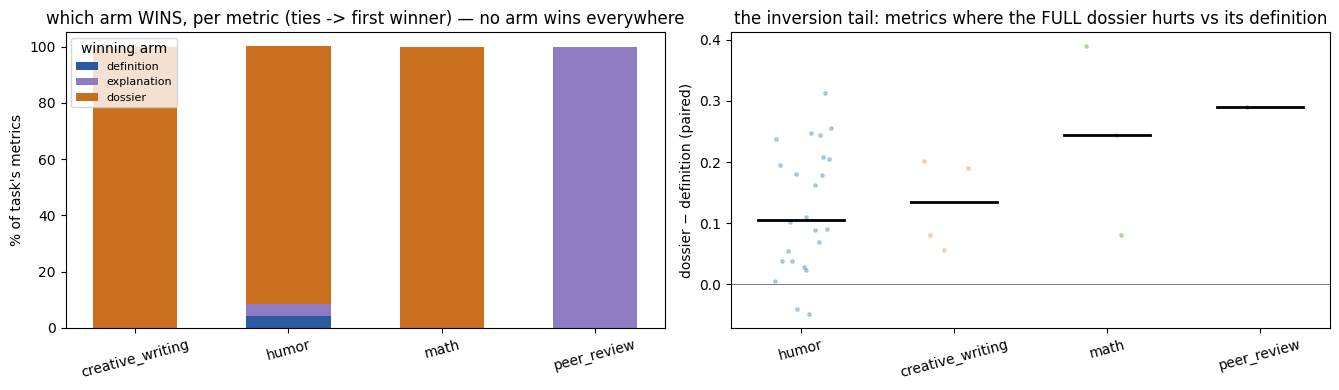

2/32 metrics lose >= .03 going definition -> dossier (more text hurts):


,task,metric,definition,dossier,dossier_minus_def
1,humor,Balancing humor with pathos,0.963,0.914,-0.049
19,humor,Self‑deprecation and willingness to be embarra...,0.896,0.856,-0.040


In [7]:
# 4.2b — where the single mean hides structure: winning arm per metric, per task; and the
# inversion tail (metrics where MORE text HURTS).
CORE = ["name", "definition", "explanation", "dossier"]
sub = df42.dropna(subset=CORE).copy()
sub["winner"] = sub[CORE].idxmax(axis=1)
tab = pd.crosstab(sub.task, sub.winner, normalize="index").mul(100).round(1)
tab = tab[[c for c in CORE if c in tab.columns]]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4))
bot = np.zeros(len(tab))
WCOL = {"name": "#9aa7b1", "definition": "#2c5aa0", "explanation": "#8e7cc3", "dossier": "#ca6f1e"}
for c in tab.columns:
    axes[0].bar(range(len(tab)), tab[c], .55, bottom=bot, color=WCOL[c], label=c)
    bot += tab[c].values
axes[0].set_xticks(range(len(tab))); axes[0].set_xticklabels(tab.index, rotation=15)
axes[0].set_ylabel("% of task's metrics"); axes[0].legend(fontsize=8, title="winning arm")
axes[0].set_title("which arm WINS, per metric (ties -> first winner) — no arm wins everywhere")
sub["dossier_minus_def"] = sub["dossier"] - sub["definition"]
for i, t in enumerate(ZTASKS):
    y = sub[sub.task == t]["dossier_minus_def"].values
    axes[1].scatter(i + _rng.uniform(-.2, .2, len(y)), y, s=6, alpha=.3)
    axes[1].plot([i - .28, i + .28], [np.median(y)] * 2, color="k", lw=2)
axes[1].axhline(0, color="gray", lw=.7)
axes[1].set_xticks(range(len(ZTASKS))); axes[1].set_xticklabels(ZTASKS, rotation=15)
axes[1].set_ylabel("dossier − definition (paired)")
axes[1].set_title("the inversion tail: metrics where the FULL dossier hurts vs its definition")
plt.tight_layout(); plt.show()
inv = sub[sub.dossier_minus_def < -.03].sort_values("dossier_minus_def")
print(f"{len(inv)}/{len(sub)} metrics lose >= .03 going definition -> dossier (more text hurts):")
display(inv[["task", "metric", "definition", "dossier", "dossier_minus_def"]].head(12).round(3))

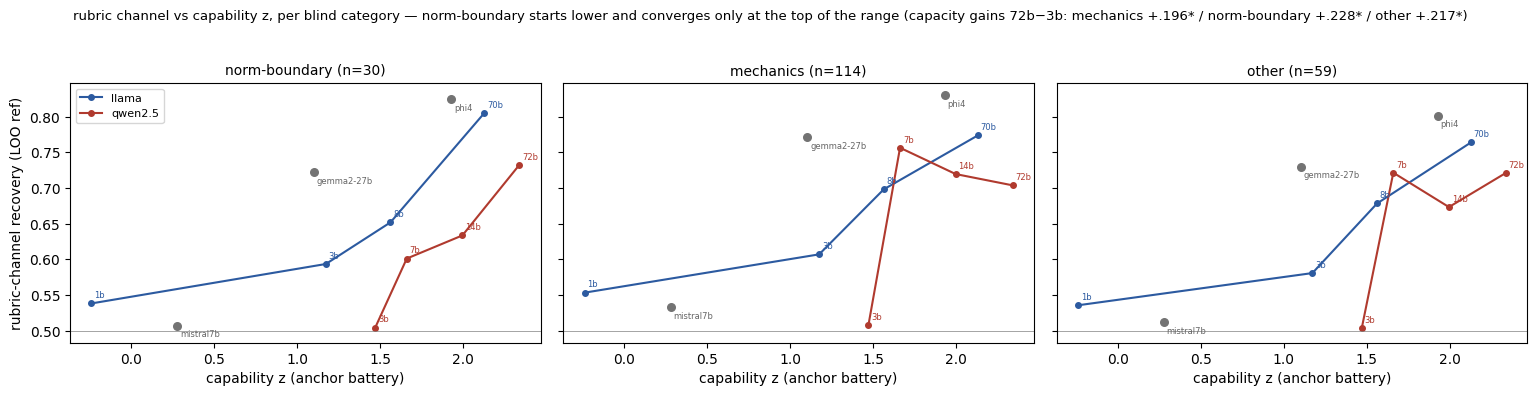

In [8]:
# 4.2c — channel x capability at bank scale, x-axis = CAPABILITY z (anchor-battery logit-AUC,
# externally validated against the OpenCompass closed-set leaderboard: r=.87 / rho=.90).
# Family-split: lines connect only same-family receivers; isolated families = points.
# gpt-oss-120b has no battery z and is excluded here (its cells appear in 4.2E-b).
ZMAP = {}
for f_ in glob.glob("data/2026-07-07-osl-multi/curves_*.json"):
    for v in json.load(open(f_)).values():
        for e_, z_ in zip(v.get("execs", []), v.get("z", [])):
            ZMAP.setdefault(e_, z_)
CH = json.load(open("../outputs/analyses/channel_scale_v2/channel_scale_v2.json"))
fig, axes = plt.subplots(1, 3, figsize=(15.5, 3.8), sharey=True)
cats = ["norm-boundary", "mechanics", "other"]
for ax, g in zip(axes, cats):
    curve = CH["bank_rubric_curves"]["category"].get(g, {})
    for fam, exes in FAMS.items():
        pts = sorted([(ZMAP[ex], curve[ex]["mean"], ex) for ex in exes
                      if curve.get(ex) and ex in ZMAP])
        if not pts: continue
        if fam == "(isolated)":
            ax.scatter([p[0] for p in pts], [p[1] for p in pts], color=FCOL[fam], s=30, zorder=3)
            for z_, y_, e_ in pts:
                ax.annotate(e_, (z_, y_), fontsize=6, xytext=(2, -8), textcoords="offset points", color="0.4")
        else:
            ax.plot([p[0] for p in pts], [p[1] for p in pts], "-o", ms=4, color=FCOL[fam], label=fam)
            for z_, y_, e_ in pts:
                ax.annotate(e_.replace("qwen25-", "").replace("llama", ""), (z_, y_), fontsize=6,
                            xytext=(2, 4), textcoords="offset points", color=FCOL[fam])
    n = max(curve[ex]["n"] for ex in curve if curve.get(ex))
    ax.set_title(f"{g} (n={n})", fontsize=10); ax.axhline(.5, color="gray", lw=.5)
    ax.set_xlabel("capability z (anchor battery)")
axes[0].set_ylabel("rubric-channel recovery (LOO ref)"); axes[0].legend(fontsize=8)
plt.suptitle("rubric channel vs capability z, per blind category — norm-boundary starts lower and converges only at the top of the range "
             "(capacity gains 72b−3b: mechanics +.196* / norm-boundary +.228* / other +.217*)", y=1.03, fontsize=9.5)
plt.tight_layout(); plt.show()

### 4.2f When does each channel start working? (emergence thresholds, decoder side)

Same 32-construct slate, all six arms, 10 local listeners, everything paired against the same frontier reference (20k bootstrap CIs). The articulation is fixed; only the **listener** grows. Three onsets, in order: **(1) executing verbatim rules** turns on between 1B and 3B — at 1B even planted mechanical rules score at chance (.509), so a 1B is learning from *no* channel; its tiny definition bump is lexical residue. **(2) extracting construct-specific content from a full articulation** (dossier − donor-swapped dossier) turns on at **7–8B** and grows monotonically without saturating locally. **(3) explanation paying beyond definition** turns on only at **32B+**; below that, mechanism text is neutral-to-harmful. Diagnostic corollary: susceptibility to the *wrong* construct's dossier grows with capability (−.03 → −.19\*) — being misleadable by text and learning from text emerge together. Caveat: gemma2-27b's battery-z is a documented invalid measurement (composite-item chance collapse) — read it by size class.

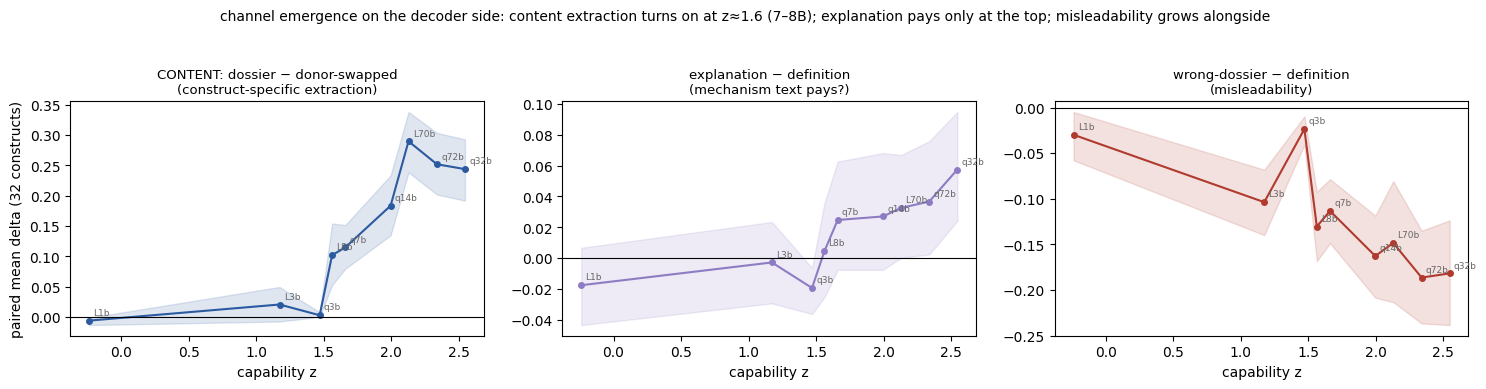

planted-rule execution (from the planted probe): .509 @1B (chance) -> .613 @3B -> .726 @8B -> ~.80 @14B+ (ceiling)


In [9]:
# 4.2f — channel-gain emergence curves (reads the saved harvest; slate n=32/arm/receiver).
EM = json.load(open("../outputs/analyses/group_contrasts_v1/channel_emergence_by_z_v1.json"))
ORDER_E = ["llama1b", "llama3b", "qwen25-3b", "llama8b", "qwen25-7b", "qwen25-14b",
           "llama70b", "qwen25-72b", "qwen25-32b"]
SHOW = [("doss CONTENT", "CONTENT: dossier − donor-swapped\n(construct-specific extraction)", "#2c5aa0"),
        ("expl-def", "explanation − definition\n(mechanism text pays?)", "#8e7cc3"),
        ("doss ANCHOR", "wrong-dossier − definition\n(misleadability)", "#b03a2e")]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.7), sharex=True)
for ax, (k, title, colr) in zip(axes, SHOW):
    zs, ms, los, his, nms = [], [], [], [], []
    for ex in ORDER_E:
        c = EM[ex]["cells"].get(k)
        if c and EM[ex]["z"] is not None:
            zs.append(EM[ex]["z"]); ms.append(c["m"]); los.append(c["ci"][0]); his.append(c["ci"][1]); nms.append(ex)
    o = np.argsort(zs)
    zs, ms, los, his = np.array(zs)[o], np.array(ms)[o], np.array(los)[o], np.array(his)[o]
    ax.fill_between(zs, los, his, color=colr, alpha=.15)
    ax.plot(zs, ms, "-o", color=colr, ms=4)
    for z_, m_, nm_ in zip(zs, ms, np.array(nms)[o]):
        ax.annotate(nm_.replace("qwen25-", "q").replace("llama", "L"), (z_, m_), fontsize=6.5,
                    xytext=(3, 4), textcoords="offset points", color="0.4")
    ax.axhline(0, color="k", lw=.8)
    ax.set_title(title, fontsize=9.5); ax.set_xlabel("capability z")
axes[0].set_ylabel("paired mean delta (32 constructs)")
plt.suptitle("channel emergence on the decoder side: content extraction turns on at z≈1.6 (7–8B); "
             "explanation pays only at the top; misleadability grows alongside", y=1.04, fontsize=10)
plt.tight_layout(); plt.show()
print("planted-rule execution (from the planted probe): .509 @1B (chance) -> .613 @3B -> .726 @8B -> ~.80 @14B+ (ceiling)")

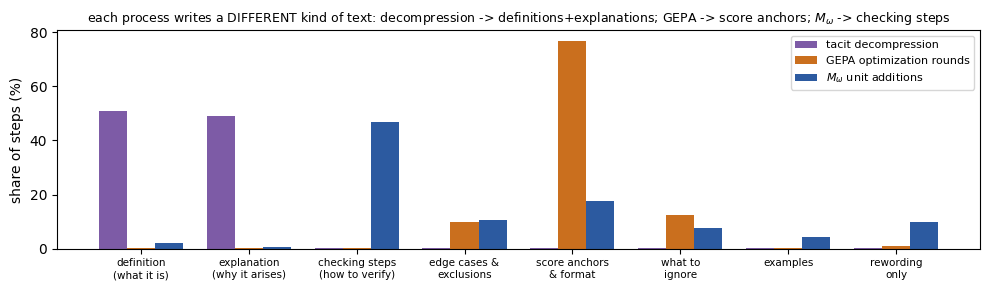

EXPLANATION (decompression-style): the step adds WHY the quality arises
----------------------------------------------------------------------------------------------------
BEFORE: A text satisfies the "Modular proof structure and dependency traceability" criterion if each step or claim is logically connected to the previous one through a clear dependency, with no ambiguity in the logical flow, and each step has a dis…
ADDED : This quality arises in a text when: | * A complex argument is broken down into smaller, manageable claims (lemmas) with clear purposes. | * Each claim is supported by explicit, logical connections to preceding statements. | * Lower-level st…
SCORE ANCHORS (GEPA-style): the step adds a scoring rule, not new meaning
----------------------------------------------------------------------------------------------------
BEFORE: Evaluate the text by following these three steps sequentially. Assign a score for each step and calculate the final average.

Step 1: Story Cohe

In [10]:
# 4.2d — what each improvement PROCESS writes into the prompt: certified shares (HB174 labels,
# parsed from the paper's generated figure) + ILLUSTRATIVE before->after snippets so the
# categories are concrete. (Snippet pairings chosen by content for illustration; the certified
# process labels are the bar values.)
TEX = open("../latex/paper-2__articulation-upper-bounds/figs/gen_change_types.tex").read()
FILLS = {"violet!25": "tacit decompression", "orange!35": "GEPA optimization rounds",
         "blue!30": "$M_\\omega$ unit additions"}
bars = re.findall(r"\\fill\[(violet!25|orange!35|blue!30)[^\]]*\] \(([\d.]+),0\) rectangle \(([\d.]+),([\d.]+)\);", TEX)
CATS = ["definition\n(what it is)", "explanation\n(why it arises)", "checking steps\n(how to verify)",
        "edge cases &\nexclusions", "score anchors\n& format", "what to\nignore", "examples", "rewording\nonly"]
series = {v: [] for v in FILLS.values()}
for fill, x0, x1, h in bars: series[FILLS[fill]].append(float(h) / 3.1 * 100)
fig, ax = plt.subplots(figsize=(10, 3))
w = 0.26
SCOL = {"tacit decompression": "#7d5ba6", "GEPA optimization rounds": "#ca6f1e",
        "$M_\\omega$ unit additions": "#2c5aa0"}
for j, (nm, vals) in enumerate(series.items()):
    ax.bar(np.arange(len(CATS)) + (j - 1) * w, vals[:len(CATS)], w, color=SCOL[nm], label=nm)
ax.set_xticks(range(len(CATS))); ax.set_xticklabels(CATS, fontsize=7.5)
ax.set_ylabel("share of steps (%)"); ax.legend(fontsize=8)
ax.set_title("each process writes a DIFFERENT kind of text: decompression -> definitions+explanations; GEPA -> score anchors; $M_\\omega$ -> checking steps", fontsize=9)
plt.tight_layout(); plt.show()
trans = [json.loads(l) for l in open("../outputs/analyses/evolution_transitions_20260728.jsonl")]
def firstwith(substr):
    for r in trans:
        a = " ".join(r.get("added") or [])
        if substr in a: return r
def snip(s, n=240): return (s[:n] + "…") if len(s) > n else s
ill = [("EXPLANATION (decompression-style): the step adds WHY the quality arises",
        firstwith("This quality arises")),
       ("SCORE ANCHORS (GEPA-style): the step adds a scoring rule, not new meaning",
        firstwith("If YES")),
       ("CHECKING STEPS ($M_\\omega$-style): the step adds a verification procedure",
        firstwith("check") or firstwith("verify"))]
for title, r in ill:
    if r is None: continue
    print("=" * 100); print(title); print("-" * 100)
    print("BEFORE:", snip(r["before"])); print("ADDED :", snip(" | ".join(r["added"])))

## 4.2E Examples — when does *showing* beat *telling*?

The examples channel: per construct, a **flip-selected** set of texts (chosen because relabeling them most changes the construct's extension) is shown in place of / beside the definition. Every claim carries the **donor-swap control** (`examples_mm` = another construct's examples): `examples − examples_mm` = construct-specific **CONTENT**; `examples_mm − definition` = generic **ANCHORING** (calibration any examples provide, regardless of which construct they come from).

### Why does gpt-oss-120b look like the big examples winner? (user question — it is NOT "thinking longer")

gpt-oss's **definition-only decoding collapses**: its traces read the definition as a *conjunctive checklist* — it enumerates the definition's clauses and answers YES only if every clause is satisfied, so it answers almost always NO (median fraction-yes **.087**, 31% of its definition channels fully degenerate in the MI census). A collapsed channel has almost no mutual information with anything. Showing it **any** examples — even donor-swapped examples of a *different* construct — resets its yes/no threshold and un-collapses the channel. That is why its examples−definition gain (+.059\*) decomposes as **anchoring +.063\* / content ≈ 0 (−.004 n.s.)**: the examples are fixing the *decoder*, not transmitting the *construct*. qwen25-72b, already calibrated (its definition channel is healthy), shows the honest picture: a small but real content gain (**+.0135\***) and a *negative* anchoring term (foreign examples mislead a calibrated judge, −.132\*). Certified by the donor-swap control + entropy diagnostic + verbatim trace reading (flip-at-frontier: the optimizer's apparent +.056\* win was 100% anchoring, fun−mm −.006 n.s.).

Exhibits: **(a)** the per-metric ledger, three judges, + the companion HTML page showing the actual prompts and exemplar texts; **(b)** the content/anchoring decomposition; **(c)** the frontier limit question on planted constructs.

metrics where examples beat the definition by >= .05 (best cell per metric):


,task,judge,definition,examples,delta
metric,,,,,
"Compressed, quotable phrasing",humor,llama70b,0.5511,0.8114,0.260
"Surprise, misdirection, and dual‑read clarity",humor,llama70b,0.6706,0.9059,0.235
"Delivery, timing, and commitment",humor,qwen25-72b,0.7361,0.9618,0.226
"Surprise, incongruity, and misdirection mechanics",humor,llama70b,0.6791,0.9002,0.221
Economy and Precision of Prose,creative_writing,llama70b,0.5718,0.7719,0.200
Observational/everyday‑life humor,humor,llama70b,0.6808,0.8808,0.200
Shared knowledge and reference accessibility,humor,qwen25-72b,0.5728,0.7529,0.180
Concrete imagery and vivid specificity,humor,llama70b,0.7491,0.9239,0.175
Cringe/awkwardness calibrated,humor,llama70b,0.7751,0.9234,0.148


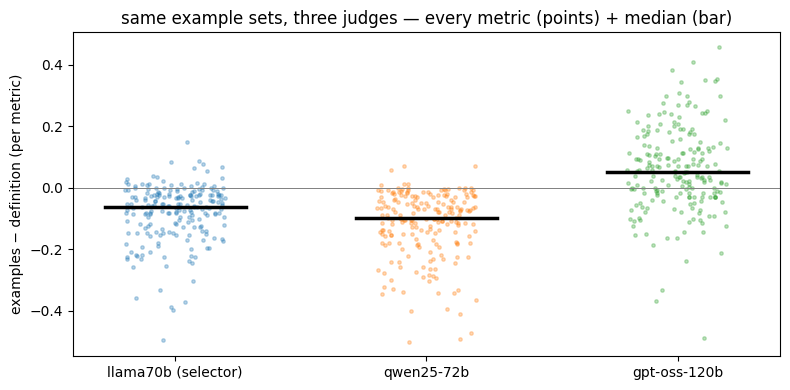

HTML companion (metrics + definition prompts + the actual exemplar texts):
  see the published artifact 'examples-vs-definitions — the actual prompts' (link in chat).


In [11]:
# 4.2E-a — examples vs definition per metric, three judges (strip + median; categorical -> no lines).
led70 = []
for s in ("llama70b", "qwen25-72b"):
    d = json.load(open(f"{D}/flips/flip_functional_v2_{s}.json"))["results"]
    for task, dd in d.items():
        if task == "news_homepages": continue     # probe-universe landmine: news joins retracted
        for base, rec in dd.items():
            for obj, po in rec.get("objectives", {}).items():
                if obj == "null": continue
                h = po.get("holdout", {})
                if h.get("functional") is not None and h.get("definition") is not None:
                    led70.append({"task": task, "metric": base, "judge": s,
                                  "definition": h["definition"], "examples": h["functional"],
                                  "delta": round(h["functional"] - h["definition"], 3)})
df70 = pd.DataFrame(led70)
best = (df70.sort_values("delta", ascending=False).groupby("metric").first()
        .sort_values("delta", ascending=False))
print("metrics where examples beat the definition by >= .05 (best cell per metric):")
display(best[best.delta >= .05][["task", "judge", "definition", "examples", "delta"]])
led = json.load(open(f"{D}/analyses/v3sets_ledger_v1.json"))
rows = []
for rcv in ("qwen25-72b", "gpt-oss-120b"):
    for r in led[rcv]:
        rows.append({"judge": rcv, "metric": r["b"],
                     "examples_minus_definition": r["functional"] - r["definition"]})
v3h = json.load(open(f"{D}/flips/flip_functional_v3_llama70b.json"))["results"]["humor"]
for b, rec in v3h.items():
    h = rec["objectives"].get("frontier2v", {}).get("holdout", {})
    if h.get("functional") is not None and h.get("definition") is not None:
        rows.append({"judge": "llama70b (selector)", "metric": b,
                     "examples_minus_definition": h["functional"] - h["definition"]})
dfr = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(8, 4))
order = ["llama70b (selector)", "qwen25-72b", "gpt-oss-120b"]
for i, j in enumerate(order):
    y = dfr[dfr.judge == j]["examples_minus_definition"].values
    ax.scatter(i + _rng.uniform(-.2, .2, len(y)), y, s=6, alpha=.3)
    ax.plot([i - .28, i + .28], [np.median(y)] * 2, color="k", lw=2.5)
ax.axhline(0, color="gray", lw=.7); ax.set_xticks(range(3)); ax.set_xticklabels(order)
ax.set_ylabel("examples − definition (per metric)")
ax.set_title("same example sets, three judges — every metric (points) + median (bar)")
plt.tight_layout(); plt.show()
print("HTML companion (metrics + definition prompts + the actual exemplar texts):")
print("  see the published artifact 'examples-vs-definitions — the actual prompts' (link in chat).")

**How to read 4.2E-b (one question per panel):** *Left* — "when a judge does better with examples than with the definition, is that because the examples carry the construct, or because any examples calibrate the judge?" Each pair of bars answers it for one judge: the CONTENT bar is examples minus donor-swapped examples (construct-specific signal survives the swap control); the ANCHORING bar is donor-swapped examples minus definition (generic calibration — the examples aren't even about this construct). qwen25-72b: small real content, negative anchoring. gpt-oss-120b: no content, all anchoring (see the mechanism note above). *Right* — the content signal, split by blind construct category: it concentrates in **norm-boundary** constructs (what a community finds acceptable/expected), and only at the calibrated judge.

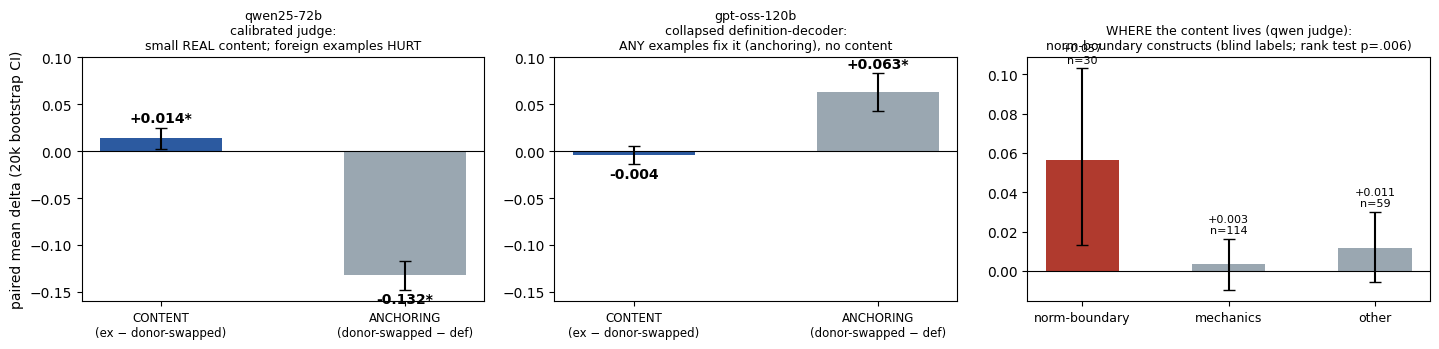

In [12]:
# 4.2E-b — content vs anchoring, one panel per judge (203 paired exemplar sets).
CAT = json.load(open(f"{D}/analyses/metric_categories_blind_v1.json"))
fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.6))
for ax, rcv, story in ((axes[0], "qwen25-72b", "calibrated judge:\nsmall REAL content; foreign examples HURT"),
                       (axes[1], "gpt-oss-120b", "collapsed definition-decoder:\nANY examples fix it (anchoring), no content")):
    rows = led[rcv]
    vals = {"CONTENT\n(ex − donor-swapped)": [r["functional"] - r["functionalmm"] for r in rows],
            "ANCHORING\n(donor-swapped − def)": [r["functionalmm"] - r["definition"] for r in rows]}
    for i, (nm, v) in enumerate(vals.items()):
        m, lo, hi = ci20(v)
        star = lo > 0 or hi < 0
        ax.bar(i, m, .5, color=["#2c5aa0", "#9aa7b1"][i])
        ax.errorbar(i, m, yerr=[[m - lo], [hi - m]], color="k", capsize=4)
        ax.text(i, (hi + .006) if m >= 0 else (lo - .014), f"{m:+.3f}{'*' if star else ''}",
                ha="center", fontsize=10, fontweight="bold")
    ax.axhline(0, color="k", lw=.8)
    ax.set_xticks(range(2)); ax.set_xticklabels(list(vals), fontsize=8.5)
    ax.set_title(f"{rcv}\n{story}", fontsize=9)
    ax.set_ylim(-.16, .10)
axes[0].set_ylabel("paired mean delta (20k bootstrap CI)")
ax = axes[2]
rows = led["qwen25-72b"]
for i, c in enumerate(["norm-boundary", "mechanics", "other"]):
    v = [r["functional"] - r["functionalmm"] for r in rows if CAT.get(r["b"]) == c]
    m, lo, hi = ci20(v)
    ax.bar(i, m, .5, color="#b03a2e" if c == "norm-boundary" else "#9aa7b1")
    ax.errorbar(i, m, yerr=[[m - lo], [hi - m]], color="k", capsize=4)
    ax.text(i, hi + .003, f"{m:+.3f}\nn={len(v)}", ha="center", fontsize=8)
ax.axhline(0, color="k", lw=.8)
ax.set_xticks(range(3)); ax.set_xticklabels(["norm-boundary", "mechanics", "other"], fontsize=9)
ax.set_title("WHERE the content lives (qwen judge):\nnorm-boundary constructs (blind labels; rank test p=.006)", fontsize=9)
plt.tight_layout(); plt.show()

**How to read 4.2E-c:** five PLANTED constructs (synthetic, so we know their decision rules) at the strongest clean receiver. Two questions. **Does content flow through examples at all?** Yes — the *gate* (examples minus donor-swapped examples) is large and positive (+.29/+.30): the receiver demonstrably extracts construct-specific signal from demonstrations. **Do demonstrations ever catch up to the written rule?** No — *examples − definition* stays negative (−.142\*): even with content certifiably flowing, the exemplar channel never reaches definition parity. **The gate opens; the gap never closes.** Corroborated on math (ex−def −.093\*, gates +.17\*) and directionally at GLM-5.2 (a reference voter, so its deltas are inflated — table below, not headlined).

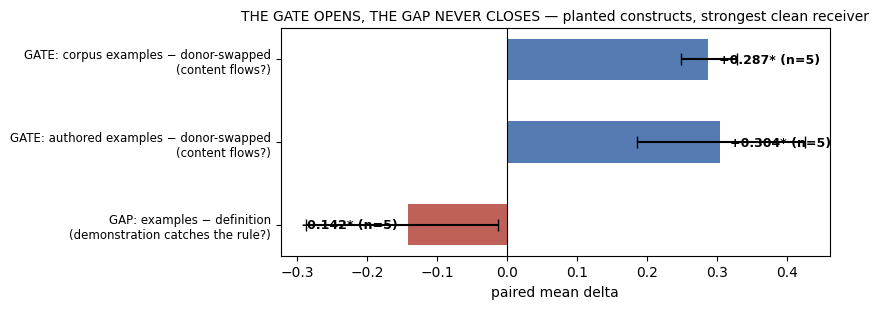

full contrast table (glm-52 is a reference VOTER — circularity inflates its deltas):


,receiver,contrast,n,mean,ci
0,gpt-oss-120b,ALL|additive,14,0.034,"[+0.001,+0.085]"
1,gpt-oss-120b,ALL|ex-def,14,-0.029,"[-0.107,+0.036]"
2,gpt-oss-120b,ALL|gate_authored,29,0.053,"[-0.002,+0.111]"
3,gpt-oss-120b,ALL|gate_corpus,14,0.100,"[+0.030,+0.176]"
4,gpt-oss-120b,DIALECT-SUSPECT|gate_authored,6,0.033,"[-0.019,+0.085]"
5,gpt-oss-120b,PLANTED|additive,5,0.015,"[+0.000,+0.045]"
6,gpt-oss-120b,PLANTED|ex-def,5,-0.142,"[-0.288,-0.013]"
7,gpt-oss-120b,PLANTED|gate_authored,5,0.304,"[+0.186,+0.426]"
8,gpt-oss-120b,PLANTED|gate_corpus,5,0.287,"[+0.248,+0.328]"
9,gpt-oss-120b,REACHES-ANCHOR|additive,9,0.044,"[-0.003,+0.121]"


In [13]:
# 4.2E-c — the limit question on PLANTED constructs, gpt-oss-120b (headline, non-voter).
FL = json.load(open(f"{D}/analyses/frontier_limit_humor_v2.json"))["receivers"]
con = FL["gpt-oss-120b"]["contrasts"]
SHOW = [("PLANTED|gate_corpus", "GATE: corpus examples − donor-swapped\n(content flows?)", "#2c5aa0"),
        ("PLANTED|gate_authored", "GATE: authored examples − donor-swapped\n(content flows?)", "#2c5aa0"),
        ("PLANTED|ex-def", "GAP: examples − definition\n(demonstration catches the rule?)", "#b03a2e")]
fig, ax = plt.subplots(figsize=(8.5, 3.2))
for i, (k, lbl, colr) in enumerate(SHOW):
    c = con[k]
    ax.barh(i, c["mean"], .5, color=colr, alpha=.8)
    ax.errorbar(c["mean"], i, xerr=[[c["mean"] - c["ci"][0]], [c["ci"][1] - c["mean"]]],
                color="k", capsize=4)
    star = "*" if c["ci"][0] > 0 or c["ci"][1] < 0 else ""
    ax.text(c["mean"] + (.015 if c["mean"] > 0 else -.015), i, f"{c['mean']:+.3f}{star} (n={c['n']})",
            va="center", ha="left" if c["mean"] > 0 else "right", fontsize=9, fontweight="bold")
ax.axvline(0, color="k", lw=.8)
ax.set_yticks(range(len(SHOW))); ax.set_yticklabels([s[1] for s in SHOW], fontsize=8.5)
ax.invert_yaxis(); ax.set_xlabel("paired mean delta")
ax.set_title("THE GATE OPENS, THE GAP NEVER CLOSES — planted constructs, strongest clean receiver", fontsize=10)
plt.tight_layout(); plt.show()
rows = []
for rcv in ("gpt-oss-120b", "glm-52"):
    for k, c in sorted(FL[rcv]["contrasts"].items()):
        rows.append({"receiver": rcv, "contrast": k, "n": c["n"], "mean": round(c["mean"], 3),
                     "ci": f"[{c['ci'][0]:+.3f},{c['ci'][1]:+.3f}]"})
print("full contrast table (glm-52 is a reference VOTER — circularity inflates its deltas):")
display(pd.DataFrame(rows))

## 4.3 Scaling laws — recovery as capability grows

### The definitions, precisely (user question 2026-08-11)

There are **two different taxonomies** in play, from two different instruments. They are related but not the same thing:

**(1) OSL fit verdicts** (`RISING / REACHES / BOUNDED / NOISY`) — per metric, from its 14-executor curve of *disattenuated* recovery $y$ vs capability $z$ (cross-family panel; $y$ divided by $\sqrt{\text{split-half reliability}}$). Fit **both** a 3-parameter logistic $y = L/(1+e^{-k(z-z_0)})$ and a straight line, compare by AICc:

- **`kneed`** := AICc(logistic) < AICc(linear) — the curve shows *statistically preferred curvature* (a bend toward an asymptote) within the observed range.
- **BOUNDED** := kneed **and** the profile-CI upper bound of the fitted ceiling, $L_{hi}$, sits **below the planted-control reference** (what synthetic fully-articulable constructs achieve on the same task; selected by capability, never by outcome). The ceiling is not merely visible — it is certifiably below "articulable."
- **REACHES** := kneed, but $L_{hi}$ is not below the planted reference — the curve bends and attains its ceiling in range, and that ceiling is consistent with full articulability.
- **RISING** := *not* kneed, and Spearman$(z,y) \ge .35$ — a monotone climb with **no detectable curvature**. (99% of rising fits put $L_{hi}>1$: the ceiling is unidentified — "rising" chiefly records censoring by our strongest executor.)
- **NOISY** := neither (excluded from all regime claims).

**So yes — a RISING and a REACHES curve can look nearly identical.** The discriminator is not the level or the visual shape but a *model-selection call on curvature* (AICc), which is exactly the kind of difference the eye can't reliably see at n≈14 points. Exhibit 4.3a below makes this concrete: same metrics, with their fitted logistics and the AICc call drawn on.

**(2) Staircase saturation groups** (`rising everywhere / family-dependent / plateaued everywhere`) — per metric, from three *within-family* staircases (llama, qwen2.5, qwen3): **yes, this one is just a threshold rule** — top rung minus mid rung recovery $> .02$ in **all** families = rising everywhere; $\le .02$ in all = plateaued everywhere; else family-dependent. It is deliberately crude and family-robust: it asks only "does the top of every ladder still buy anything," with no fit, no extrapolation. The fit verdicts extrapolate; the saturation groups don't. When they disagree, the saturation group is the conservative claim.

### How the upper bound is established (user question)

Two different "ceilings" appear in 4.3a, neither hand-set:
1. **The fitted ceiling $L$** — the asymptote parameter of the per-metric logistic fit, with a **profile-likelihood CI** $[L_{lo}, L_{hi}]$ (re-fit the curve holding $L$ fixed at candidate values; the CI is where fit quality stays within the likelihood threshold). It says where *this metric's own curve* is heading. For rising curves it is unidentified ($L_{hi} > 1$ for 99%) — that is *why* they are classed rising.
2. **The planted reference** (dash-dot line) — the *instrument's* ceiling for the task: the mean recovery of the top planted controls, where planted constructs are synthetic criteria with known, fully-articulable decision rules. Selection of which planted controls define it is **by capability z, never by outcome** (top-k by z), so the reference can't be cherry-picked upward. If a real metric's $L_{hi}$ sits below what *fully articulable* constructs achieve on the same probes/judges, the shortfall is a property of the construct, not the instrument — that is the BOUNDED certificate.

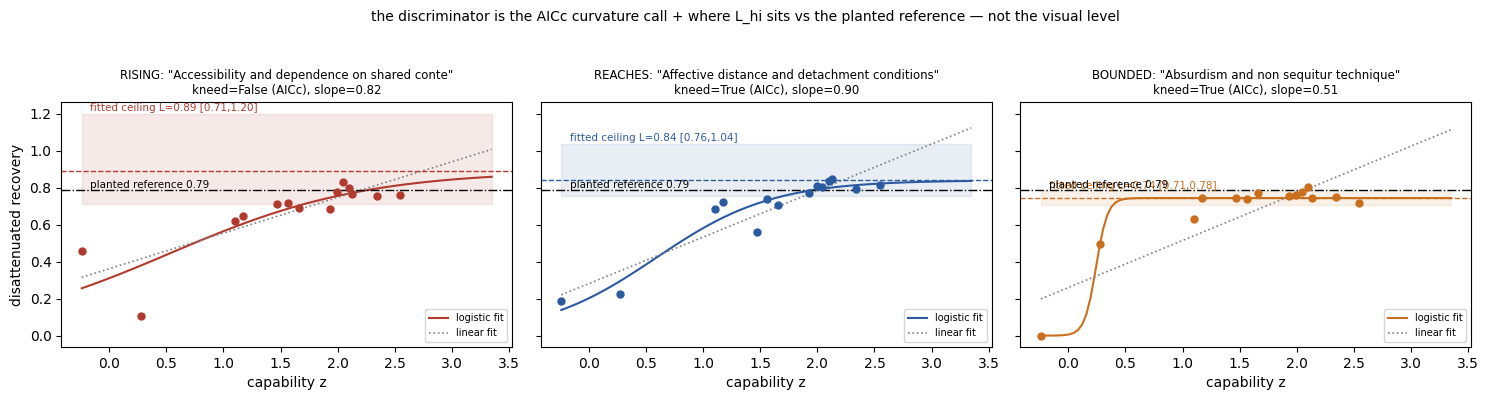

humor bank: verdict x kneed cross-tab: {(True, 'BOUNDED'): 41, (True, 'REACHES'): 114, (False, 'RISING'): 123, (False, 'NOISY'): 6}


In [14]:
# 4.3a — CAN you see RISING vs REACHES? Exemplars with their fits and the AICc call.
from scipy.optimize import curve_fit
laws = {r["name"]: r for r in json.load(open("data/2026-07-07-osl-multi/laws_humor.json"))["rows"]}
ceil_h = json.load(open("data/2026-07-07-osl-multi/laws_humor.json"))["ceiling"]
cur_h = json.load(open("data/2026-07-07-osl-multi/curves_humor.json"))
def logi(z, L, k, z0): return L / (1 + np.exp(-k * (z - z0)))
picks = []
for vd in ("RISING", "REACHES", "BOUNDED"):
    cands = [n for n, r in laws.items() if r.get("verdict") == vd and cur_h.get(n, {}).get("z")
             and len(cur_h[n]["z"]) >= 10]
    cands.sort(key=lambda n: -laws[n].get("n", 0))
    picks.append((vd, cands[0]))
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
for ax, (vd, n) in zip(axes, picks):
    c, r = cur_h[n], laws[n]
    z, y = np.array(c["z"]), np.array(c["y"])
    ax.scatter(z, np.clip(y, 0, 1.1), s=25, color=RCOL[vd], zorder=3)
    zz = np.linspace(z.min(), z.max() + .8, 100)
    try:
        p, _ = curve_fit(logi, z, y, p0=[.8, 2, .5], bounds=([.2, .1, -2], [1.2, 20, 4]), maxfev=5000)
        ax.plot(zz, logi(zz, *p), color=RCOL[vd], lw=1.5, label="logistic fit")
    except Exception: pass
    b = np.polyfit(z, y, 1)
    ax.plot(zz, np.polyval(b, zz), color="0.5", lw=1.2, ls=":", label="linear fit")
    if r.get("L") is not None:
        ax.axhline(r["L"], color=RCOL[vd], ls="--", lw=1)
        ax.fill_between(zz, r["L_lo"], r["L_hi"], color=RCOL[vd], alpha=.10)
        ax.text(zz[2], r["L_hi"] + .015, f"fitted ceiling L={r['L']:.2f} [{r['L_lo']:.2f},{r['L_hi']:.2f}]",
                fontsize=7.5, color=RCOL[vd])
    ax.axhline(ceil_h, color="k", ls="-.", lw=1)
    ax.text(zz[2], ceil_h + .015, f"planted reference {ceil_h:.2f}", fontsize=7.5)
    ax.set_title(f"{vd}: \"{n[:44]}\"\nkneed={r['kneed']} (AICc), slope={r['slope']:.2f}", fontsize=8.5)
    ax.set_xlabel("capability z"); ax.legend(fontsize=7, loc="lower right")
axes[0].set_ylabel("disattenuated recovery")
plt.suptitle("the discriminator is the AICc curvature call + where L_hi sits vs the planted reference — not the visual level", y=1.04, fontsize=10)
plt.tight_layout(); plt.show()
kn = [(r.get("kneed"), r.get("verdict")) for r in laws.values()]
print("humor bank: verdict x kneed cross-tab:", dict(Counter(kn)))

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_39300/2930357253.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[k.lower() for _, k in panels], showfliers=False, patch_artist=True)


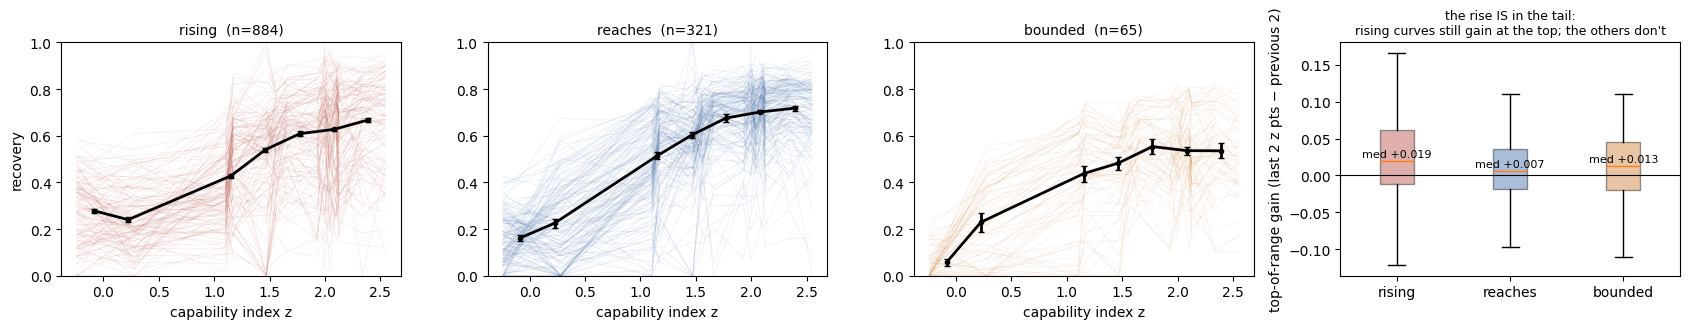

verdict counts: {'RISING': 884, 'REACHES': 321, 'NOISY': 77, 'BOUNDED': 65}


In [15]:
# 4.3b — the fitted-regime panels + CAN YOU SEE THE RISE? Right-most panel: the top-of-range
# gain (mean of last-2 z points minus mean of the previous 2) per metric — rising curves are
# still buying recovery at the top of the range; reaches/bounded are not.
CURVES = []
for f in sorted(glob.glob("data/2026-07-07-osl-multi/curves_*.json")):
    dom = os.path.basename(f)[7:-5]
    for name, v in json.load(open(f)).items():
        if v.get("kind") != "bank": continue
        z, y = v.get("z"), v.get("y")
        if z and y and len(z) == len(y) and len(z) >= 6:
            CURVES.append((v.get("verdict"), dom, name, z, y))
def binned_mean(rows, B=9):
    zs = [a for _, _, _, z, _ in rows for a in z]
    edges = np.linspace(min(zs), max(zs), B + 1)
    out = []
    for i in range(B):
        vals = [min(1, max(0, b)) for _, _, _, z, y in rows
                for a, b in zip(z, y) if edges[i] <= a < edges[i + 1] + (1e-9 if i == B - 1 else 0)]
        if len(vals) >= 20:
            out.append(((edges[i] + edges[i + 1]) / 2, np.mean(vals), 1.96 * np.std(vals) / np.sqrt(len(vals))))
    return out
fig, axes = plt.subplots(1, 4, figsize=(17, 3.4))
panels = [(k.lower(), k) for k in ("RISING", "REACHES", "BOUNDED")]
for ax, (title, vd) in zip(axes[:3], panels):
    rows = [r for r in CURVES if r[0] == vd]
    for verd, _, _, z, y in rows[::max(1, len(rows) // 120)]:
        ax.plot(z, np.clip(y, 0, 1), color=RCOL.get(verd, "0.6"), alpha=.10, lw=.5)
    bm = binned_mean(rows)
    ax.errorbar([b[0] for b in bm], [b[1] for b in bm], yerr=[b[2] for b in bm],
                color="k", lw=2, marker="o", ms=3, capsize=2)
    ax.set_title(f"{title}  (n={len({(r[1], r[2]) for r in rows})})", fontsize=10)
    ax.set_xlabel("capability index z"); ax.set_ylim(0, 1)
    ax.sharey(axes[0])
axes[0].set_ylabel("recovery")
topgain = {k: [] for _, k in panels}
for vd, _, _, z, y in CURVES:
    if vd not in topgain: continue
    o = np.argsort(z); yy = np.array(y)[o]
    topgain[vd].append(float(np.mean(yy[-2:]) - np.mean(yy[-4:-2])))
ax = axes[3]
data = [topgain[k] for _, k in panels]
bp = ax.boxplot(data, labels=[k.lower() for _, k in panels], showfliers=False, patch_artist=True)
for p, (_, k) in zip(bp["boxes"], panels): p.set_facecolor(RCOL[k]); p.set_alpha(.4)
ax.axhline(0, color="k", lw=.8)
for i, d in enumerate(data):
    ax.text(1 + i, np.median(d) + .005, f"med {np.median(d):+.3f}", ha="center", fontsize=8)
ax.set_ylabel("top-of-range gain (last 2 z pts − previous 2)")
ax.set_title("the rise IS in the tail:\nrising curves still gain at the top; the others don't", fontsize=9)
plt.tight_layout(); plt.show()
print("verdict counts:", dict(Counter(r[0] for r in CURVES)))

**Where "in the text / at the interface / beyond the text" comes from (user question):** every criterion was blind-labeled (regime withheld from the labeler) with a 9-type task-agnostic codebook of *what the criterion asks about* — two independent passes, 9-type κ = .75, coarse-axis κ = .73. The coarse axis is then a **fixed deterministic mapping** of those 9 types by where the criterion's truth conditions live: mechanical checks, craft operations, evidence & rigor, holistic taste → **in the text** (a reader with only the artifact can verify); audience fit, community transformation → **at the interface** (needs a model of the audience/community); identity & persona, external bundles, reception outcomes → **beyond the text** (truth depends on facts outside the artifact — who wrote it, what happened after). The externality index is the mean of (0, ½, 1) over that mapping. No re-labeling happens at the coarse step, so the axis inherits the blind labels' reliability.

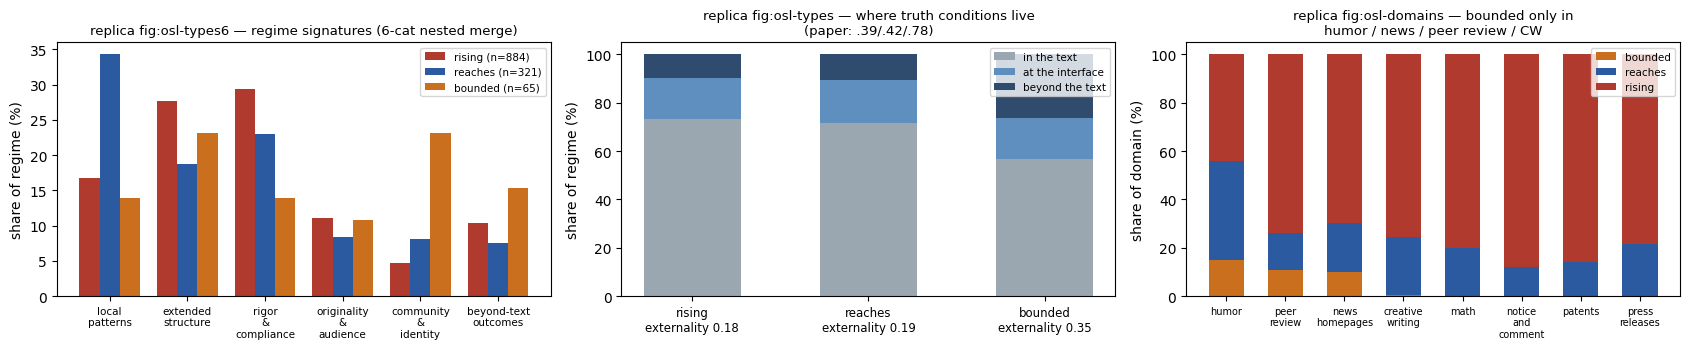

In [16]:
# 4.3c — what KIND of criterion lands in each regime (replica: fig:osl-types6 nested merge,
# coarse truth-condition axis, regime-by-domain).
T = json.load(open("../outputs/analyses/osl_metric_types_20260728.json"))
KEY = T["key"]
L12 = {i: (v["label"] if isinstance(v, dict) else v) for i, v in T["labels_12type"].items()}
L9 = {i: (v["label"] if isinstance(v, dict) else v) for i, v in T["labels"].items()}
M6 = {"COMPACT_DEVICE": "local patterns", "EXTENDED_STRUCTURE": "extended structure",
      "SURFACE_CHECK": "rigor & compliance", "ETHICS_HARM": "rigor & compliance",
      "VERIFICATION_SOURCING": "rigor & compliance", "LOGICAL_RIGOR": "rigor & compliance",
      "ORIGINALITY_NOVELTY": "originality & audience", "AUDIENCE_FIT": "originality & audience",
      "COMMUNITY_STANCE": "community & identity", "IDENTITY_PERSONA": "community & identity",
      "ECOSYSTEM_ARTIFACTS": "beyond-text outcomes", "RECEPTION_OUTCOME": "beyond-text outcomes"}
CATS6 = list(dict.fromkeys(M6[k] for k in M6))
REG = ["RISING", "REACHES", "BOUNDED"]
AX9 = {"MECHANICAL_CHECK": 0, "CRAFT_OPERATION": 0, "EVIDENCE_RIGOR": 0, "HOLISTIC_TASTE": 0,
       "AUDIENCE_FIT": 1, "COMMUNITY_TRANSFORM": 1,
       "IDENTITY_PERSONA": 2, "EXTERNAL_BUNDLE": 2, "RECEPTION_OUTCOME": 2}
fig, axes = plt.subplots(1, 3, figsize=(17, 3.6))
n_reg = {r: sum(1 for i in L12 if KEY[i]["verdict"] == r) for r in REG}
w = 0.26
for j, r in enumerate(REG):
    shares = [100 * sum(1 for i in L12 if KEY[i]["verdict"] == r and M6[L12[i]] == c) / n_reg[r] for c in CATS6]
    axes[0].bar(np.arange(len(CATS6)) + (j - 1) * w, shares, w, color=RCOL[r], label=f"{r.lower()} (n={n_reg[r]})")
axes[0].set_xticks(range(len(CATS6)))
axes[0].set_xticklabels([c.replace(" & ", " &\n").replace(" ", "\n", 1) for c in CATS6], fontsize=7.5)
axes[0].set_ylabel("share of regime (%)"); axes[0].legend(fontsize=7.5)
axes[0].set_title("replica fig:osl-types6 — regime signatures (6-cat nested merge)", fontsize=9.5)
AXN = ["in the text", "at the interface", "beyond the text"]
bot = np.zeros(len(REG)); ACOL = ["#9aa7b1", "#5f8fbf", "#2f4b6e"]
for a in (0, 1, 2):
    shares = [100 * sum(1 for i in L9 if KEY[i]["verdict"] == r and AX9[L9[i]] == a) / n_reg[r] for r in REG]
    axes[1].bar(range(len(REG)), shares, 0.55, bottom=bot, color=ACOL[a], label=AXN[a])
    bot += np.array(shares)
ext = {r: np.mean([AX9[L9[i]] / 2 for i in L9 if KEY[i]["verdict"] == r]) for r in REG}
axes[1].set_xticks(range(len(REG)))
axes[1].set_xticklabels([f"{r.lower()}\nexternality {ext[r]:.2f}" for r in REG], fontsize=8.5)
axes[1].set_ylabel("share of regime (%)"); axes[1].legend(fontsize=7.5)
axes[1].set_title("replica fig:osl-types — where truth conditions live\n(paper: .39/.42/.78)", fontsize=9.5)
dom_reg = {}
for i, k in KEY.items(): dom_reg.setdefault(k["dom"], Counter())[k["verdict"]] += 1
doms = sorted(dom_reg, key=lambda d: -dom_reg[d]["BOUNDED"] / max(1, sum(dom_reg[d].values())))
bot = np.zeros(len(doms))
for r in ("BOUNDED", "REACHES", "RISING"):
    shares = [100 * dom_reg[d][r] / sum(dom_reg[d].values()) for d in doms]
    axes[2].bar(range(len(doms)), shares, 0.6, bottom=bot, color=RCOL[r], label=r.lower())
    bot += np.array(shares)
axes[2].set_xticks(range(len(doms))); axes[2].set_xticklabels([d.replace("_", "\n") for d in doms], fontsize=7)
axes[2].set_ylabel("share of domain (%)"); axes[2].legend(fontsize=7.5)
axes[2].set_title("replica fig:osl-domains — bounded only in\nhumor / news / peer review / CW", fontsize=9.5)
plt.tight_layout(); plt.show()

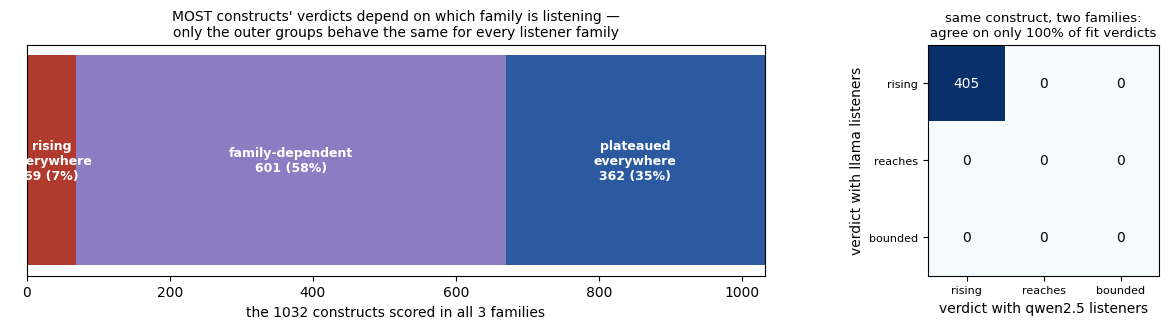

TAKEAWAY: 'how far does capability take you' has no family-free answer for most constructs;
regime labels are (construct, listener-family) properties. This is why panels are never pooled.


In [17]:
# 4.3d — three-family census. ONE question: is a construct's scaling verdict a property of
# the construct, or of the (construct, listener-family) pair?
sg = Counter(satgroup(r) for r in FJ)
n_scored = sg["rising everywhere"] + sg["family-dependent"] + sg["plateaued everywhere"]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axes[0]
left = 0
for g, colr in (("rising everywhere", "#b03a2e"), ("family-dependent", "#8e7cc3"),
                ("plateaued everywhere", "#2c5aa0")):
    ax.barh(0, sg[g], left=left, color=colr, height=.5)
    ax.text(left + sg[g] / 2, 0, f"{g.replace(' ', chr(10))}\n{sg[g]} ({100*sg[g]/n_scored:.0f}%)",
            ha="center", va="center", fontsize=9, color="w", fontweight="bold")
    left += sg[g]
ax.set_xlim(0, n_scored); ax.set_yticks([]); ax.set_xlabel(f"the {n_scored} constructs scored in all 3 families")
ax.set_title("MOST constructs' verdicts depend on which family is listening —\n"
             "only the outer groups behave the same for every listener family", fontsize=10)
VN = ["RISING", "REACHES", "BOUNDED"]
M = np.zeros((3, 3))
for r in FJ:
    a, b = r["verdict3"].get("llama"), r["verdict3"].get("qwen25")
    if a in VN and b in VN: M[VN.index(a), VN.index(b)] += 1
ax = axes[1]
ax.imshow(M, cmap="Blues")
for i in range(3):
    for j in range(3):
        ax.text(j, i, int(M[i, j]), ha="center", va="center",
                color="w" if M[i, j] > M.max() / 2 else "k", fontsize=10)
ax.set_xticks(range(3)); ax.set_xticklabels([v.lower() for v in VN], fontsize=8)
ax.set_yticks(range(3)); ax.set_yticklabels([v.lower() for v in VN], fontsize=8)
ax.set_xlabel("verdict with qwen2.5 listeners"); ax.set_ylabel("verdict with llama listeners")
ax.set_title(f"same construct, two families:\nagree on only {100*np.trace(M)/M.sum():.0f}% of fit verdicts", fontsize=9.5)
plt.tight_layout(); plt.show()
print("TAKEAWAY: 'how far does capability take you' has no family-free answer for most constructs;")
print("regime labels are (construct, listener-family) properties. This is why panels are never pooled.")

### 4.3d2 The pooled fit and the within-family staircase disagree — and which one to trust

The fit verdicts (RISING/REACHES/BOUNDED) are computed on the **pooled** 14-executor cross-family panel; the staircase groups and certified plateaus are **within-family**. They intend the same claim ("solved with scale?") but disagree in practice: most certified plateau-at-high constructs are *fitted* RISING. Mechanism: the pooled curve's top end mixes executors from different families, so apparent late gains can be **family-composition variance** (crossing into another family's reference dialect) rather than capability growth — the same artifact the bounded-audit's DIALECT-SUSPECT class catches on the bounded side. Note the observational-scaling-laws pooling license (Ruan, Maddison & Hashimoto 2024) does not transfer here: it holds for benchmark accuracy explained by shared capability dimensions, while our outcome carries reference-dialect structure that is not a capability dimension. **Instrument of record: within-family** (certified plateaus for "solved"; the 69-construct rising-in-all-3-families tail for "still gaining"); pooled verdicts are curve-shape descriptions of the panel, and pooled-RISING-not-high is equally suspect.

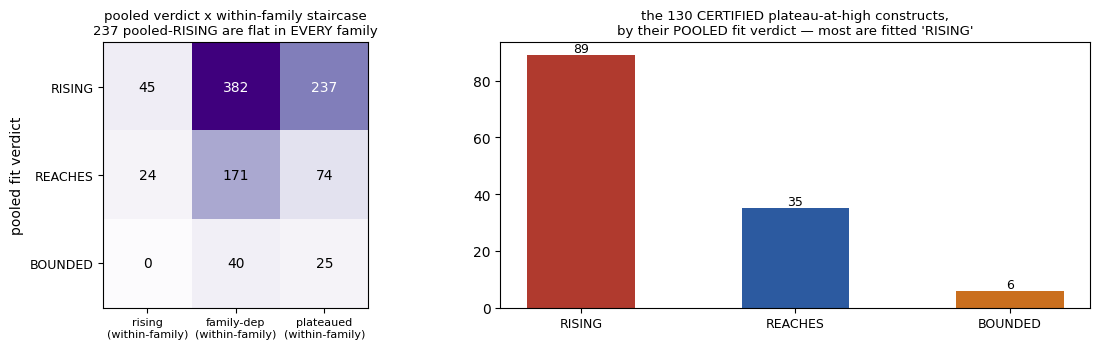

When the instruments disagree, within-family wins: pooled late gains at top-z are dialect
composition, not growth. Paper counts 884/321/65 = pooled-panel descriptions, not certificates.


In [18]:
# 4.3d2 — cross-tab: pooled fit verdict x within-family staircase group; certified-plateau overlap.
MT = json.load(open("../outputs/analyses/group_contrasts_v1/master_table_v1.json"))
RFR = {(r["task"], r["name"]): r for r in
       json.load(open("../outputs/analyses/reliability_filter_v1/reliability_filter_v1.json"))["rows"]
       if r.get("status") == "ok"}
ct = Counter()
for r in MT:
    if r.get("oslv") in ("RISING", "REACHES", "BOUNDED") and r.get("sat"):
        ct[(r["oslv"], r["sat"])] += 1
SATS = ["rising", "family-dep", "plateaued"]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
M = np.array([[ct[(v, s)] for s in SATS] for v in ("RISING", "REACHES", "BOUNDED")])
im = axes[0].imshow(M, cmap="Purples")
for i_ in range(3):
    for j_ in range(3):
        axes[0].text(j_, i_, M[i_, j_], ha="center", va="center",
                     color="w" if M[i_, j_] > M.max() / 2 else "k", fontsize=10)
axes[0].set_xticks(range(3)); axes[0].set_xticklabels([s + "\n(within-family)" for s in SATS], fontsize=8)
axes[0].set_yticks(range(3)); axes[0].set_yticklabels(["RISING", "REACHES", "BOUNDED"], fontsize=9)
axes[0].set_ylabel("pooled fit verdict")
axes[0].set_title(f"pooled verdict x within-family staircase\n{ct[('RISING','plateaued')]} pooled-RISING are flat in EVERY family", fontsize=9.5)
rel = [k for k, r in RFR.items() if r.get("reliable_plateau")]
cv = Counter(r.get("oslv") for r in MT if (r["task"], r["name"]) in rel)
axes[1].bar(range(len(cv)), [c for _, c in cv.most_common()],
            color=[RCOL.get(k, "0.6") for k, _ in cv.most_common()], width=.5)
axes[1].set_xticks(range(len(cv))); axes[1].set_xticklabels([k for k, _ in cv.most_common()], fontsize=9)
for i_, (k, c) in enumerate(cv.most_common()):
    axes[1].text(i_, c + 1, str(c), ha="center", fontsize=9)
axes[1].set_title(f"the {len(rel)} CERTIFIED plateau-at-high constructs,\nby their POOLED fit verdict — most are fitted 'RISING'", fontsize=9.5)
plt.tight_layout(); plt.show()
print("When the instruments disagree, within-family wins: pooled late gains at top-z are dialect")
print("composition, not growth. Paper counts 884/321/65 = pooled-panel descriptions, not certificates.")

### 4.3j Does construct *content* predict the verdict? The norm-boundary test at full scale

All 1,347 metric names blind-categorized (norm-boundary / mechanics / other; extension wave consistency vs the original judge: 28/30). Result: **within humor the prediction is strong and strengthens** — P(RISING | norm-boundary) = .805 vs .380 for the rest (n=41, perm p<1e-5). **Pooled across 8 domains it does not generalize** (p=.19) — but the base rates show why: outside humor, banks are 70–79% RISING (deeply censored), leaving almost no verdict variance to predict. The claim of record is humor-scoped: *where a bank has verdict diversity, social-acceptability constructs keep gaining with capability while craft mechanics finish early.* Testing generalization needs the other banks' censoring broken (stronger within-family ladders), not more labels.

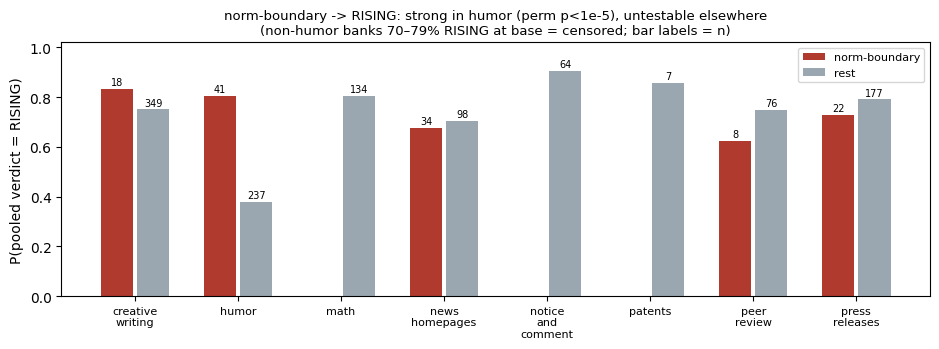

In [19]:
# 4.3j — norm-boundary -> RISING, full universe (blind categories v2).
CAT2 = json.load(open(f"{D}/analyses/metric_categories_blind_v2.json"))["labels"]
sub = [r for r in MT if r.get("oslv") in ("RISING", "REACHES", "BOUNDED")
       and CAT2.get(r["task"] + "||" + r["name"])]
for r in sub: r["cat2"] = CAT2[r["task"] + "||" + r["name"]]
tasks_n = sorted({r["task"] for r in sub})
fig, ax = plt.subplots(figsize=(9.5, 3.6))
w = .35
for j, grp in enumerate(("norm-boundary", "rest")):
    xs, ys, ns = [], [], []
    for i_, t in enumerate(tasks_n):
        tr = [r for r in sub if r["task"] == t]
        g = [r for r in tr if (r["cat2"] == "norm-boundary") == (grp == "norm-boundary")]
        if len(g) < 5: xs.append(i_); ys.append(np.nan); ns.append(len(g)); continue
        xs.append(i_); ys.append(np.mean([r["oslv"] == "RISING" for r in g])); ns.append(len(g))
    ax.bar(np.array(xs) + (j - .5) * w, ys, w * .9,
           color="#b03a2e" if grp == "norm-boundary" else "#9aa7b1", label=grp)
    for x_, y_, n_ in zip(xs, ys, ns):
        if np.isfinite(y_): ax.text(x_ + (j - .5) * w, y_ + .015, str(n_), ha="center", fontsize=7)
ax.set_xticks(range(len(tasks_n))); ax.set_xticklabels([t.replace("_", "\n") for t in tasks_n], fontsize=8)
ax.set_ylabel("P(pooled verdict = RISING)"); ax.legend(fontsize=8)
ax.set_title("norm-boundary -> RISING: strong in humor (perm p<1e-5), untestable elsewhere\n(non-humor banks 70–79% RISING at base = censored; bar labels = n)", fontsize=9.5)
ax.set_ylim(0, 1.02)
plt.tight_layout(); plt.show()

**How to read 4.3e:** *Left panel asks:* of the constructs whose curves went flat in **every** family, how many flat curves are **real ceilings** — vs artifacts of a bad reference? A curve can be flat because the two reference voters barely agree (noisy target), because too few items survived their agreement filter, or because no receiver ever recovered the construct anywhere (nothing was being transmitted in the first place — a *different* claim than "articulable ceiling reached"). Only the blue bar — flat at HIGH recovery against a RELIABLE reference — certifies "this construct is transmitted as well as it will ever be." *Right panel:* the practical output — each of the 1,032 constructs assigned the remedy its evidence supports (Collins' three routes + null cases). The modal remedy is a **dialect-matched listener** — not a bigger one.

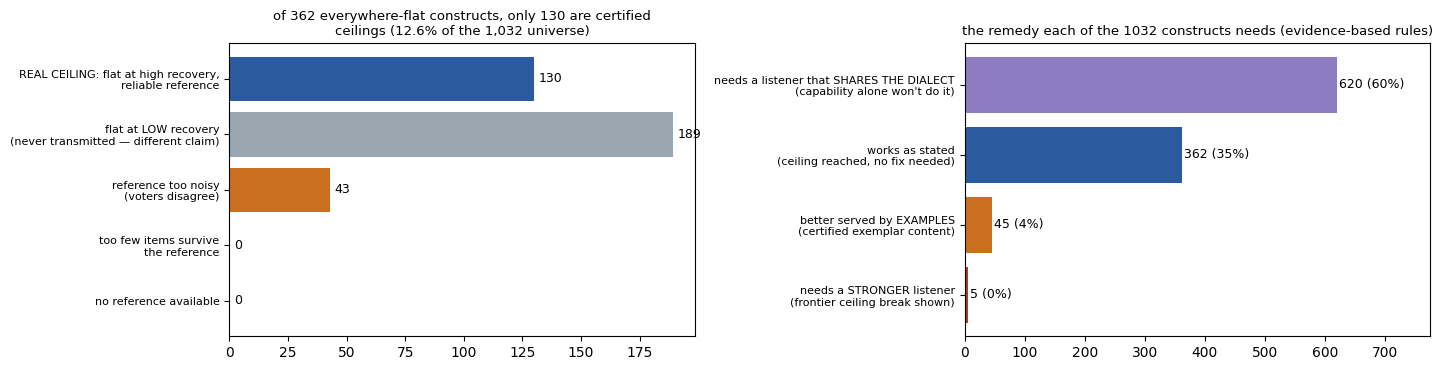

In [20]:
# 4.3e — which flat curves are REAL ceilings + what fix each construct needs.
RF = json.load(open("../outputs/analyses/reliability_filter_v1/reliability_filter_v1.json"))["rows"]
VT = json.load(open("../outputs/analyses/verdict_table_v1/verdict_table_v1.json"))["rows"]
def fail_mode(r):
    if r["status"] != "ok": return "no reference available"
    if r["reliable_plateau"]: return "REAL CEILING: flat at high recovery,\nreliable reference"
    if r["agreement"] < .70: return "reference too noisy\n(voters disagree)"
    if r["kept_n"] < 150: return "too few items survive\nthe reference"
    return "flat at LOW recovery\n(never transmitted — different claim)"
fm = Counter(fail_mode(r) for r in RF)
fig, axes = plt.subplots(1, 2, figsize=(14.5, 3.8))
keys = ["REAL CEILING: flat at high recovery,\nreliable reference",
        "flat at LOW recovery\n(never transmitted — different claim)",
        "reference too noisy\n(voters disagree)", "too few items survive\nthe reference",
        "no reference available"]
cols = ["#2c5aa0", "#9aa7b1", "#ca6f1e", "#caa46f", "0.75"]
axes[0].barh(range(len(keys)), [fm.get(k, 0) for k in keys], color=cols)
for i, k in enumerate(keys):
    axes[0].text(fm.get(k, 0) + 2, i, str(fm.get(k, 0)), va="center", fontsize=9)
axes[0].set_yticks(range(len(keys))); axes[0].set_yticklabels(keys, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_title(f"of {len(RF)} everywhere-flat constructs, only {fm.get(keys[0], 0)} are certified\n"
                  f"ceilings ({100*fm.get(keys[0],0)/1032:.1f}% of the 1,032 universe)", fontsize=9.5)
REN = {"dialect-matched-listener": "needs a listener that SHARES THE DIALECT\n(capability alone won't do it)",
       "works-as-stated / none-needed": "works as stated\n(ceiling reached, no fix needed)",
       "better-demonstration": "better served by EXAMPLES\n(certified exemplar content)",
       "stronger-listener": "needs a STRONGER listener\n(frontier ceiling break shown)",
       "nothing-certified": "nothing certified"}
rem = Counter(REN.get(r["remedy"], r["remedy"]) for r in VT)
labels, vals = zip(*rem.most_common())
axes[1].barh(range(len(labels)), vals, color=["#8e7cc3", "#2c5aa0", "#ca6f1e", "#b03a2e", "0.6", "0.8"][:len(labels)])
for i, v in enumerate(vals):
    axes[1].text(v + 4, i, f"{v} ({100*v/len(VT):.0f}%)", va="center", fontsize=9)
axes[1].set_yticks(range(len(labels))); axes[1].set_yticklabels(labels, fontsize=8)
axes[1].invert_yaxis(); axes[1].set_xlim(0, max(vals) * 1.25)
axes[1].set_title(f"the remedy each of the {len(VT)} constructs needs (evidence-based rules)", fontsize=9.5)
plt.tight_layout(); plt.show()

**How to read 4.3f:** the 69 constructs still gaining at the top of the local ladder ("censored" — our strongest local judge wasn't strong enough to see their ceiling). Question: if we hand them to a much stronger judge (gpt-oss-120b), do the curves keep climbing? Each dot compares the frontier judge (y) to the best clean local judge (x) against the *same local reference*. Dots **on or below the diagonal** = no, the frontier does not continue the climb — because the reference speaks the local voters' dialect, and the frontier judge, however capable, is being graded on dialect agreement. Red circles = the 5 genuine ceiling breaks. Takeaway: what looked like "not enough capability" is mostly **reference-dialect binding** — you cannot buy your way past it with parameters.

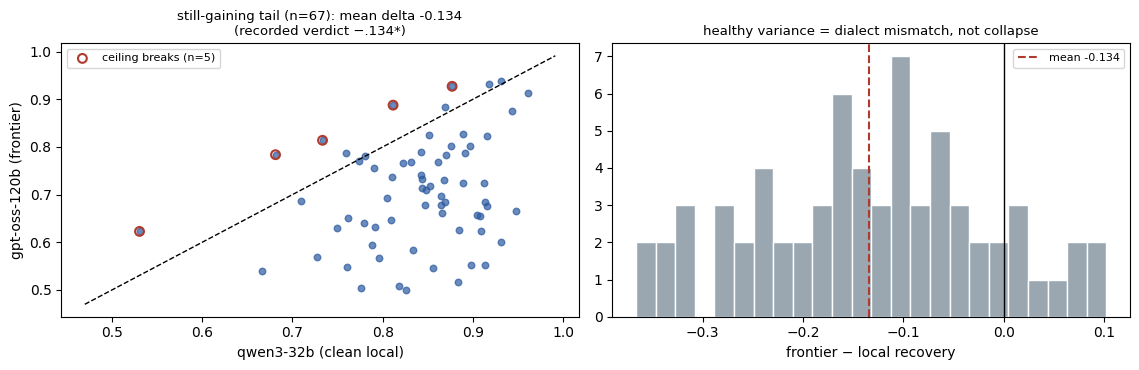

Under the LOCAL-dialect reference, frontier capability does not uncap the tail: the rising
asymptote stays unidentified — a listener-DIALECT bound, not a z bound.


In [21]:
# 4.3f — the frontier does not de-censor the still-gaining tail (69 constructs; x = best
# clean local comparator qwen3-32b, y = gpt-oss-120b, both vs the local 2-voter reference).
DH = {r["b"]: r for r in json.load(open(f"{D}/analyses/decensor_harvest_v1.json"))}
TAIL = [tuple(r) if isinstance(r, list) else (r["task"], r["name"])
        for r in json.load(open(f"{D}/flips/decensor_tail_v1.json"))]
xs, ys = [], []
for t, n in TAIL:
    r = DH.get(n)
    if r and r.get("qwen3-32b") is not None and r.get("gptoss") is not None:
        xs.append(r["qwen3-32b"]); ys.append(r["gptoss"])
xs, ys = np.array(xs), np.array(ys); d = ys - xs
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
axes[0].scatter(xs, ys, s=22, alpha=.7, color="#2c5aa0")
lim = [min(xs.min(), ys.min()) - .03, max(xs.max(), ys.max()) + .03]
axes[0].plot(lim, lim, "k--", lw=1)
brk = d >= .05
axes[0].scatter(xs[brk], ys[brk], s=40, facecolors="none", edgecolors="#b03a2e", lw=1.5,
                label=f"ceiling breaks (n={brk.sum()})")
axes[0].set_xlabel("qwen3-32b (clean local)"); axes[0].set_ylabel("gpt-oss-120b (frontier)")
axes[0].legend(fontsize=8)
axes[0].set_title(f"still-gaining tail (n={len(xs)}): mean delta {d.mean():+.3f}\n(recorded verdict −.134*)", fontsize=9.5)
axes[1].hist(d, bins=24, color="#9aa7b1", edgecolor="w")
axes[1].axvline(0, color="k", lw=1); axes[1].axvline(d.mean(), color="#b03a2e", lw=1.5, ls="--", label=f"mean {d.mean():+.3f}")
axes[1].set_xlabel("frontier − local recovery"); axes[1].legend(fontsize=8)
axes[1].set_title("healthy variance = dialect mismatch, not collapse", fontsize=9.5)
plt.tight_layout(); plt.show()
print("Under the LOCAL-dialect reference, frontier capability does not uncap the tail: the rising")
print("asymptote stays unidentified — a listener-DIALECT bound, not a z bound.")

**How to read 4.3g:** every judge-channel emits binary predictions; a channel that answers (almost) always the same thing has (almost) zero entropy H(pred), and mutual information with ANY construct is capped by H(pred). Left: the share of fully-degenerate channels per receiver — small receivers collapse on most constructs (qwen2.5-3b: ~90–100% constant), which is *why* staircases floor at small z: the channel is broken, not the construct absent. Right: the median entropy cap itself. Read every low-z recovery number in this notebook against this census.

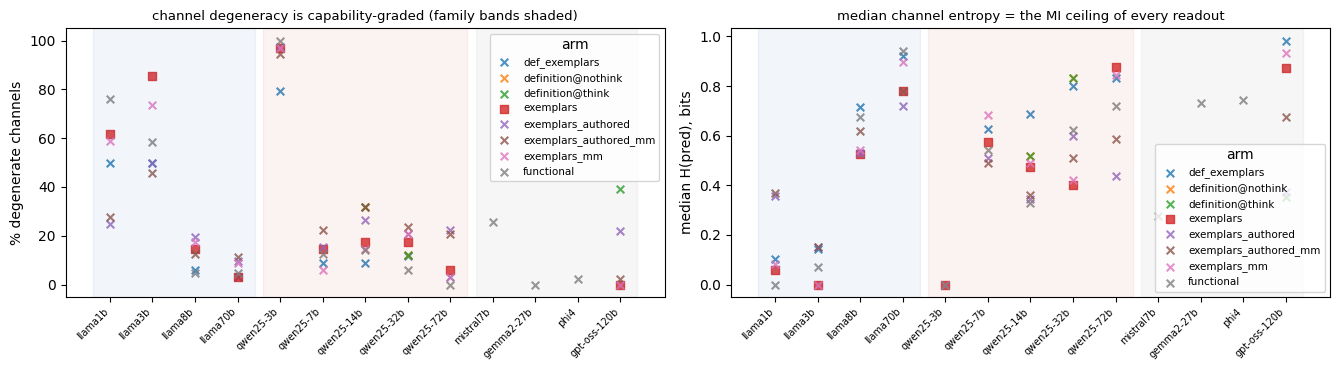

Small-z recovery floors are CHANNEL COLLAPSE (near-constant predictions), not construct absence.


In [22]:
# 4.3g — instrument health: the MI upper-bound census. Dot plot per receiver (grouped by
# family, no cross-family lines): % degenerate channels and median H(pred) — the hard MI
# ceiling of every readout at that receiver.
MI = pd.DataFrame(json.load(open(f"{D}/analyses/mi_upper_census_v2.json"))["rows"])
ORDER = [e for fam in FAMS.values() for e in fam if e in set(MI["ex"])]
sub = MI[MI["ex"].isin(ORDER)]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 3.8))
ms = {"definition": "o", "exemplars": "s", "name": "^", "dossier": "D"}
for arm, g in sub.groupby("arm"):
    st_ = g.groupby("ex").agg(deg=("degenerate", "mean"), H=("H_pred", "median")).reindex(ORDER)
    x = np.arange(len(ORDER))
    axes[0].scatter(x, 100 * st_["deg"], marker=ms.get(arm, "x"), s=30, label=arm, alpha=.8)
    axes[1].scatter(x, st_["H"], marker=ms.get(arm, "x"), s=30, label=arm, alpha=.8)
for ax in axes:
    ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER, rotation=45, ha="right", fontsize=7)
    for fam, exes in FAMS.items():
        idx = [ORDER.index(e) for e in exes if e in ORDER]
        if idx: ax.axvspan(min(idx) - .4, max(idx) + .4, color=FCOL[fam], alpha=.06)
axes[0].set_ylabel("% degenerate channels"); axes[0].legend(fontsize=7.5, title="arm")
axes[0].set_title("channel degeneracy is capability-graded (family bands shaded)", fontsize=9.5)
axes[1].set_ylabel("median H(pred), bits"); axes[1].legend(fontsize=7.5, title="arm")
axes[1].set_title("median channel entropy = the MI ceiling of every readout", fontsize=9.5)
plt.tight_layout(); plt.show()
print("Small-z recovery floors are CHANNEL COLLAPSE (near-constant predictions), not construct absence.")

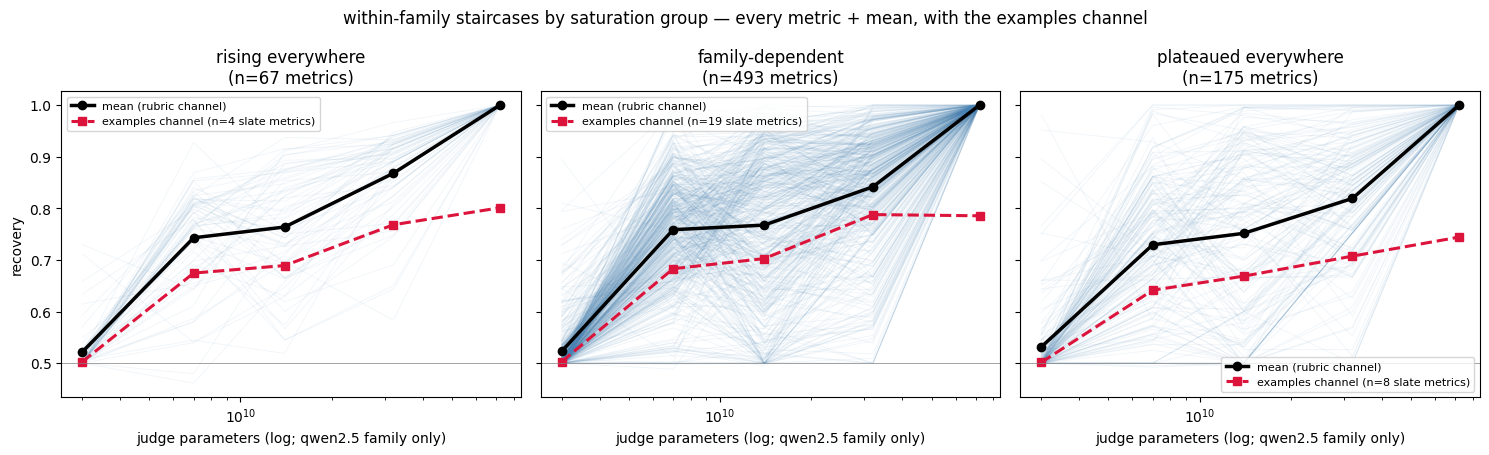

{'rising everywhere': 67, 'family-dependent': 493, 'plateaued everywhere': 175}


In [23]:
# 4.3h — within-family staircases by saturation group (qwen2.5 family; a connected line is
# meaningful HERE because every point is the same family), with the examples channel overlay.
QF = ["qwen25-3b", "qwen25-7b", "qwen25-14b", "qwen25-32b", "qwen25-72b"]
QP = [3e9, 7e9, 14e9, 32e9, 72e9]
def crowd(task, ex):
    d = {}
    if task == "humor":
        d.update(lp(f"{D}/crowd_panels/mbar285_{ex}.npz")); d.update(lp(f"{D}/crowd_panels/mbar2_humor_sup_{ex}.npz"))
    else:
        d.update(lp(f"{D}/crowd_panels/mbar2_{task}_{ex}.npz"))
    return d
CR = {t: {ex: crowd(t, ex) for ex in QF + ["llama70b"]} for t in TASKS}
def cref(task, base):
    votes = []
    for ex in ("llama70b", "qwen25-72b"):
        r = CR[task].get(ex, {}).get(base)
        if r is not None: votes.append((np.asarray(r, float) > .5).astype(float))
    if len(votes) < 2: return None
    m = np.stack(votes).mean(0)
    return np.where(m > .5, 1, np.where(m < .5, 0, -1))
curves = {}
for r in FJ:
    t, b = r["task"], r["name"]
    g = GROUP[(t, b)]
    if g is None: continue
    lab = cref(t, b)
    if lab is None: continue
    ys = []
    for ex in QF:
        v = CR[t].get(ex, {}).get(b)
        ys.append(balanced(np.asarray(v, float), lab) if v is not None else None)
    if sum(y is not None for y in ys) >= 4:
        curves.setdefault(g, []).append((t, b, ys))
lad = {ex: lp(f"{D}/flips/mbar_flipladder_{ex}.npz") for ex in QF}
ex_curves = {}
for key in lad[QF[-1]]:
    if "functional_llama70b_frontier" not in key: continue
    t, rest = key.split("|", 1)
    b = rest.split("||")[0]
    g = GROUP.get((t, b))
    if g is None or t not in ZTASKS: continue
    lab = ref_for(t, b)
    if lab is None: continue
    ys = []
    for ex in QF:
        r = lad[ex].get(key)
        ys.append(balanced(np.asarray(r, float), lab) if r is not None else None)
    if sum(y is not None for y in ys) >= 4:
        ex_curves.setdefault(g, []).append(ys)
GORDER = ["rising everywhere", "family-dependent", "plateaued everywhere"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for ax, g in zip(axes, GORDER):
    cs = curves.get(g, [])
    for t, b, ys in cs:
        xs_ = [p for p, y in zip(QP, ys) if y is not None]
        ax.semilogx(xs_, [y for y in ys if y is not None], color="steelblue", alpha=.07, lw=.7)
    mean = [np.mean([ys[i] for _, _, ys in cs if ys[i] is not None]) for i in range(len(QF))]
    ax.semilogx(QP, mean, color="k", lw=2.5, marker="o", label="mean (rubric channel)")
    ec = ex_curves.get(g, [])
    if ec:
        em = [np.mean([ys[i] for ys in ec if ys[i] is not None]) for i in range(len(QF))]
        ax.semilogx(QP, em, color="crimson", lw=2.2, ls="--", marker="s",
                    label=f"examples channel (n={len(ec)} slate metrics)")
    ax.set_title(f"{g}\n(n={len(cs)} metrics)"); ax.axhline(.5, color="gray", lw=.5)
    ax.set_xlabel("judge parameters (log; qwen2.5 family only)"); ax.legend(fontsize=8)
axes[0].set_ylabel("recovery")
fig.suptitle("within-family staircases by saturation group — every metric + mean, with the examples channel")
plt.tight_layout(); plt.show()
print({g: len(curves.get(g, [])) for g in GORDER})

**How to read 4.3i:** we froze a 5-rung "how much articulation does this construct need" ladder from the transmission data (R1 name suffices → R5 nothing certified works), *then* scored the preregistered predictions that the ladder should track lexical abstractness. It doesn't: P1 — within every domain, deeper-rung (harder-to-transmit) constructs are worded **more** concretely, not less (red bars = significant); P2 — beyond-text constructs, predicted to pile up at deep rungs, are actually most common at R1, because naming a familiar convention ("timeliness and topicality") transmits it perfectly. The ladder measures something the wording's abstractness does not capture — consistent with 4.2E: what resists transmission is the decision rule, not the vocabulary.

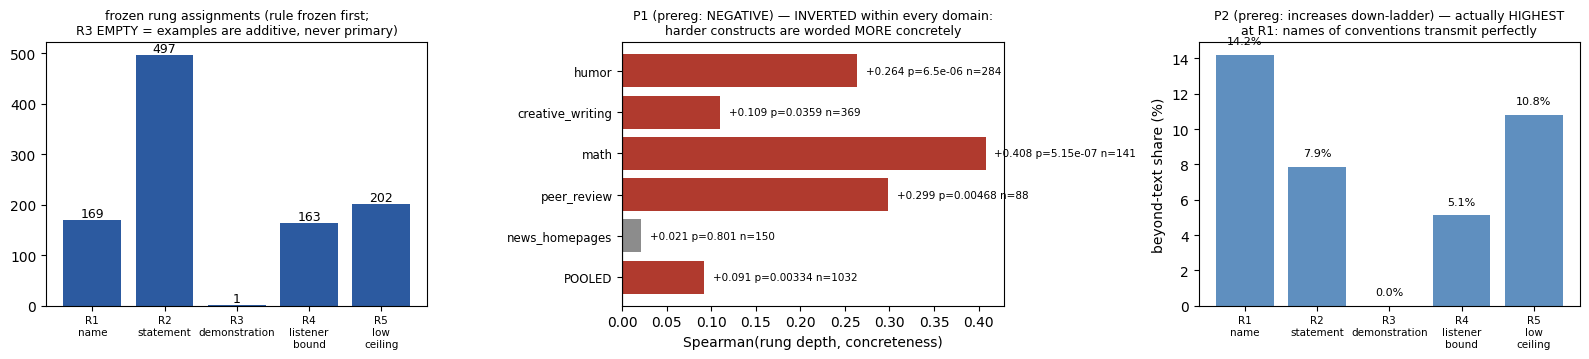

PREREG LANDING (frozen zone 3): the operational ladder does not reduce to lexical abstractness.


In [24]:
# 4.3i — the operational ladder (criterion 5): frozen rungs, then the preregistered
# abstractness tests. P1 uses the AUDITED instrument (expanded function-word list +
# suffix lemmatizer + Brysbaert norms); committed reference values 2026-08-11:
# humor +.264*** / math +.397*** / peer +.287** / CW +.114* / news +.010 n.s.; pooled +.092.
LAD = json.load(open("../outputs/analyses/ladder_p123_v1/ladder_p123_v1.json"))["rows"]
RUNGS = ["R1-name", "R2-statement", "R3-demonstration", "R4-listener-bound", "R5-low-ceiling"]
CONC = {}
for rec in csv.DictReader(open(f"{D}/analyses/brysbaert_concreteness.csv"), delimiter="\t"):
    try: CONC[rec["Word"].lower()] = float(rec["Conc.M"])
    except (ValueError, KeyError): pass
FUNC = set(('''the a an and or but nor of to in for with on by at from into over under as that this
these those it its they them their there here is are was were be been being am do does did done
have has had having will would shall should can could may might must not no yes if then else when
while which who whom whose what where why how all any some none each every either neither both few
many much more most other another such only own same so than too very just also again further once
about against between through during before after above below up down out off again very'''.split()))
def lemma(w):
    for suf, rep in (("ies", "y"), ("es", ""), ("s", ""), ("ing", ""), ("ing", "e"), ("ed", ""), ("ed", "e")):
        if w.endswith(suf) and len(w) > len(suf) + 2:
            cand = w[:len(w) - len(suf)] + rep
            if cand in CONC: return cand
    return w
DEFS = {}
for t in TASKS:
    for m in json.load(open(f"{D}/code_metrics/defs_{t}.json")): DEFS[(t, m["name"])] = m["definition"]
def conc_of(text):
    toks = [w for w in re.findall(r"[a-z]+", text.lower()) if w not in FUNC]
    vals = [CONC[lemma(w)] for w in toks if lemma(w) in CONC]
    return float(np.mean(vals)) if len(vals) >= 5 else None
for r in LAD:
    r["conc2"] = conc_of(r["name"] + " " + DEFS.get((r["task"], r["name"]), ""))
fig, axes = plt.subplots(1, 3, figsize=(16, 3.7))
rc = Counter(r["rung"] for r in LAD)
axes[0].bar(range(len(RUNGS)), [rc[g] for g in RUNGS], color="#2c5aa0")
for i, g in enumerate(RUNGS): axes[0].text(i, rc[g] + 6, str(rc[g]), ha="center", fontsize=9)
axes[0].set_xticks(range(len(RUNGS))); axes[0].set_xticklabels([g.replace("-", "\n") for g in RUNGS], fontsize=7.5)
axes[0].set_title("frozen rung assignments (rule frozen first;\nR3 EMPTY = examples are additive, never primary)", fontsize=9)
ok = [r for r in LAD if r["conc2"] is not None]
rows, labels = [], []
for t in TASKS:
    s_ = [r for r in ok if r["task"] == t]
    rho, p = sps.spearmanr([r["rung_idx"] for r in s_], [r["conc2"] for r in s_])
    rows.append((rho, p, len(s_))); labels.append(t)
prho, pp = sps.spearmanr([r["rung_idx"] for r in ok], [r["conc2"] for r in ok])
rows.append((prho, pp, len(ok))); labels.append("POOLED")
for i, ((rho, p, n), lb) in enumerate(zip(rows, labels)):
    axes[1].barh(i, rho, color="#b03a2e" if p < .05 else "0.55")
    axes[1].text(rho + (.01 if rho >= 0 else -.01), i, f"{rho:+.3f} p={p:.3g} n={n}",
                 va="center", ha="left" if rho >= 0 else "right", fontsize=7.5)
axes[1].axvline(0, color="k", lw=.8)
axes[1].set_yticks(range(len(labels))); axes[1].set_yticklabels(labels, fontsize=8.5)
axes[1].invert_yaxis(); axes[1].set_xlabel("Spearman(rung depth, concreteness)")
axes[1].set_title("P1 (prereg: NEGATIVE) — INVERTED within every domain:\nharder constructs are worded MORE concretely", fontsize=9)
sh = []
for g in RUNGS:
    s_ = [r for r in LAD if r["rung"] == g and r["axis"] is not None]
    sh.append(100 * np.mean([r["axis"] == 2 for r in s_]) if s_ else np.nan)
axes[2].bar(range(len(RUNGS)), sh, color="#5f8fbf")
for i, v in enumerate(sh):
    if np.isfinite(v): axes[2].text(i, v + .6, f"{v:.1f}%", ha="center", fontsize=8)
axes[2].set_xticks(range(len(RUNGS))); axes[2].set_xticklabels([g.replace("-", "\n") for g in RUNGS], fontsize=7.5)
axes[2].set_ylabel("beyond-text share (%)")
axes[2].set_title("P2 (prereg: increases down-ladder) — actually HIGHEST\nat R1: names of conventions transmit perfectly", fontsize=9)
plt.tight_layout(); plt.show()
print("PREREG LANDING (frozen zone 3): the operational ladder does not reduce to lexical abstractness.")

## Appendix — supervised anchors (context only; not part of the unsupervised story)

Table 1 rows-of-record and the supervised Qwen3 ladder, for cross-reference with §3 of the paper.

,benchmark,GEPA,GEPA+Merge,MIPROv2,eps-cert (M_omega),Delta vs GEPA
0,HotpotQA,0.411,0.400,0.439,0.646,+.235***
1,HoVer,0.471,0.517,NaN,0.557,"+.086*** (re-mint at 10,110-call parity: +.066..."
2,LiveBench,0.699,0.688,0.677,0.705,+.006 n.s.
3,IFBench,0.403,0.411,0.383,0.443,+.040**
4,AIME,0.385,0.373,0.323,0.392,+.007 n.s.
5,PUPA,0.883,NaN,NaN,0.882,-.001 — RE-MINT IN FLIGHT on sk1 2026-08-11 (f...


,task,corrected rho (MI vs judge-vs-silver AUC)
0,peer-review,0.68
1,code-review,0.62
2,creative-writing,0.61
3,math,0.56
4,press-releases,0.50
5,humor,0.45


Table 2 design (HELD result — the paper's validity anchor): WITHIN-metric across its own
prompt forms; attenuation-corrected; code-review confirmed out-of-sample vs a prereg stratum.


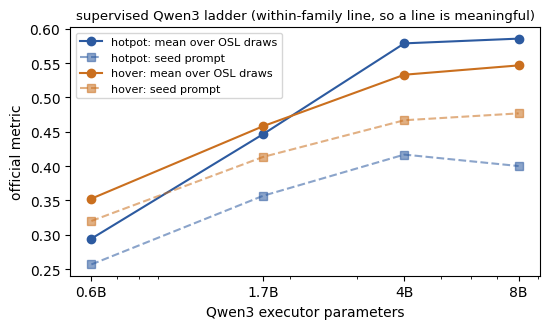

In [25]:
# A.1 — Table 1 + Table 2 as printed (with live re-mint status), and the supervised ladder.
import statistics as st
t1 = pd.DataFrame([
    ["HotpotQA", .411, .400, .439, .646, "+.235***"],
    ["HoVer", .471, .517, None, .557, "+.086*** (re-mint at 10,110-call parity: +.066* [.040,.093])"],
    ["LiveBench", .699, .688, .677, .705, "+.006 n.s."],
    ["IFBench", .403, .411, .383, .443, "+.040**"],
    ["AIME", .385, .373, .323, .392, "+.007 n.s."],
    ["PUPA", .883, None, None, .882, "-.001 — RE-MINT IN FLIGHT on sk1 2026-08-11 (fresh same-session: GEPA .9062 / MIPROv2 .8831 / Merge .8442; M_omega pending)"],
], columns=["benchmark", "GEPA", "GEPA+Merge", "MIPROv2", "eps-cert (M_omega)", "Delta vs GEPA"])
display(t1)
t2 = pd.DataFrame([["peer-review", .68], ["code-review", .62], ["creative-writing", .61],
                   ["math", .56], ["press-releases", .50], ["humor", .45]],
                  columns=["task", "corrected rho (MI vs judge-vs-silver AUC)"])
display(t2)
print("Table 2 design (HELD result — the paper's validity anchor): WITHIN-metric across its own")
print("prompt forms; attenuation-corrected; code-review confirmed out-of-sample vs a prereg stratum.")
PAR = {"Qwen3-0.6B": 0.6, "Qwen3-1.7B": 1.7, "Qwen3-4B": 4.0, "Qwen3-8B": 8.0}
BC = {"hotpot": "#2c5aa0", "hover": "#ca6f1e"}
pts = {}
for f in sorted(glob.glob("../datasets/prompt-optimality-test/runs/osl_*.json")):
    d = json.load(open(f))
    b, mn = d.get("bench"), d.get("model")
    if b not in BC or mn not in PAR: continue
    dr = [x["score"] for x in (d.get("draws") or []) if x.get("score") is not None]
    if d.get("init") is None or len(dr) < 20: continue
    pts.setdefault(b, []).append((PAR[mn], d["init"], st.mean(dr)))
fig, ax = plt.subplots(figsize=(5.6, 3.4))
for b, rows in sorted(pts.items()):
    rows.sort()
    ax.plot([r[0] for r in rows], [r[2] for r in rows], "-o", color=BC[b], label=f"{b}: mean over OSL draws")
    ax.plot([r[0] for r in rows], [r[1] for r in rows], "--s", color=BC[b], alpha=.55, label=f"{b}: seed prompt")
ax.set_xscale("log"); ax.set_xticks([0.6, 1.7, 4, 8]); ax.set_xticklabels(["0.6B", "1.7B", "4B", "8B"])
ax.set_xlabel("Qwen3 executor parameters"); ax.set_ylabel("official metric")
ax.set_title("supervised Qwen3 ladder (within-family line, so a line is meaningful)", fontsize=9.5)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

---
### Canonical artifacts (quote these, not notebook recomputations)

| claim | artifact |
|---|---|
| unit codability labels (3,458 units, 6/6 anchors ×3 crews) | `outputs/articulation_story_20260810/code_metrics/unit_codability_<task>.json` |
| channel arms + references (zxa panels) | `outputs/articulation_story_20260810/zxa_panels/` |
| examples ledgers (two receivers, mm controls) | `.../analyses/v3sets_ledger_v1.json` (certified deltas: content +.0135\* qwen / anchoring +.0628\* gptoss) |
| blind construct categories (30/114/59) | `.../analyses/metric_categories_blind_v1.json` |
| frontier limit (gate/gap, both receivers) | `.../analyses/frontier_limit_humor_v2.json` |
| OSL fit verdicts + curves (RISING/REACHES/BOUNDED rule: AICc logistic-vs-linear + planted-ref comparison, see 4.3 header) | `notebooks/data/2026-07-07-osl-multi/{curves,laws}_*.json`; fit code `methods/metric_implementer/experiments/osl_staged_20260808/panel_analysis.py` |
| three-family census (threshold rule top−mid .02) | `.../analyses/family_verdict_join_v1.json` |
| reliability screen thresholds + rows | `outputs/analyses/reliability_filter_v1/` |
| remedy verdicts (criterion 4) | `outputs/analyses/verdict_table_v1/` |
| de-censor harvest + tail | `.../analyses/decensor_harvest_v1.json`, `.../flips/decensor_tail_v1.json` |
| MI census | `.../analyses/mi_upper_census_v2.json` |
| frozen rungs + P1/P2 (committed audit values in notes 2026-08-11) | `outputs/analyses/ladder_p123_v1/`; `notes/2026-08-05__direction12-battery-plan.md` |
| 9/12-type labels (κ=.75) | `outputs/analyses/osl_metric_types_20260728.json` |
| change-types (HB174) | parsed from `latex/paper-2__articulation-upper-bounds/figs/gen_change_types.tex` |
| Table-1 rows-of-record | `notes/2026-07-19__gepa-consolidation-and-momega-upgrade-plan.md` (FINAL TABLE 1 + HB204) |

| seam width F (A/(V+A), held-out, certified) | figure constants from `latex/.../gen_fig_seam_spectrum.py`; harnesses `methods/metric_seam/battery/` |
| channel emergence by z | `outputs/analyses/group_contrasts_v1/channel_emergence_by_z_v1.json` |
| group contrasts + master table | `outputs/analyses/group_contrasts_v1/` |
| blind categories v2 (1,347; overlap 28/30) | `outputs/articulation_story_20260810/analyses/metric_categories_blind_v2.json` |

**Open coverage items**: PUPA re-mint completing on sk1.